<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/12_sensitivity_diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB12 — Sensibilidade Compacta e Robustez das Escolhas

## 1. Papel deste notebook no pipeline

O NB12 examina a robustez das decisões metodológicas consolidadas no NB10 e avaliadas no NB11. O NB10 delimitou cenários temporalmente defensáveis; o NB11 comparou baselines e modelos tabulares sob validação temporal; o NB12 verifica se a referência principal permanece sustentada quando são consideradas variações moderadas de limiar e persistência.

A etapa é deliberadamente compacta. Ela não repete a comparação ampla de modelos nem reabre o espaço completo de 72 cenários. O modelo vencedor do NB11 é mantido fixo, permitindo atribuir as diferenças observadas às configurações de cenário avaliadas.

## 2. Objetivo

Verificar se o cenário principal `W5_K24_H12_P1_TRAIN_M2S` permanece metodologicamente defensável diante de cenários de sensibilidade, preservando:

1. o `TimeSeriesSplit` como protocolo principal;
2. o corte temporal fixo 80/20 como análise complementar;
3. a família `TRAIN_M2S` como referência governante;
4. `train_p95` e `P3` como sensibilidades;
5. `global_m2s` como referência retrospectiva;
6. `train_p99` como severidade extrema descritiva;
7. os escores como ordenações relativas de risco temporal.

## 3. Entradas esperadas

### 3.1 Artefatos do NB10

- `10_scenario_decisions.csv`;
- `10_scenario_series_states.parquet`;
- `10_scenario_episodes.parquet`;
- resumos descritivos e de limiares, quando disponíveis.

Esses artefatos fornecem as decisões de cenário, as séries rotuladas e os episódios usados na análise de sensibilidade.

### 3.2 Artefatos do NB11

- `11_winner_model.json`;
- `11_feature_sets.json`;
- `11_nb11_summary.json`, quando disponível;
- `11_metrics_summary.csv`, quando disponível;
- `11_baselines_summary.csv`, quando disponível.

O NB12 lê diretamente a especificação do vencedor e o contrato de atributos materializados pelo NB11.

## 4. Decisão herdada do NB11

A referência principal recebida pelo NB12 é:

| Item | Valor |
|---|---|
| Cenário | `W5_K24_H12_P1_TRAIN_M2S` |
| Conjunto de atributos | `temporal_core` |
| Modelo | Regressão Logística |
| Número de atributos | 13 |
| F1 médio no TSCV | 0,577 |
| Recall médio no TSCV | 0,834 |
| Precisão média no TSCV | 0,482 |
| ROC-AUC médio no TSCV | 0,647 |
| Average Precision média no TSCV | 0,559 |

O modelo é mantido fixo durante a sensibilidade. A calibração foi avaliada no NB11, mas não foi adotada como camada operacional; por isso, as saídas permanecem interpretadas como **escores relativos de risco temporal**.

## 5. Contrato normativo de atributos

Os conjuntos principais são:

```python
raw_core = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_LOST_count",
]
```

```python
temporal_core = raw_core + [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]
```

`raw_core` contém 6 atributos e `temporal_core` contém 13. A coluna `event_FAIL_count` permanece nos dados para proveniência e auditoria, mas não integra o vetor preditivo. Antes do treinamento, o notebook verifica:

- igualdade entre `n_failed` e `event_FAIL_count`;
- cardinalidades 6/13;
- nomes únicos;
- ausência de alvo, estado, identificadores e informação futura;
- ausência de `event_FAIL_count` nos preditores;
- inexistência de duplicidade exata não justificada entre os atributos efetivamente usados.

Qualquer não conformidade interrompe a execução antes do treinamento.

## 6. Escopo da sensibilidade

| Elemento | Tratamento |
|---|---|
| `train_m2s` | Referência principal herdada do NB10/NB11 |
| `train_p95` | Sensibilidade de limiar |
| `P3` | Sensibilidade restritiva de persistência |
| `global_m2s` | Referência histórica retrospectiva |
| `train_p99` | Severidade extrema apenas descritiva |
| `sensitivity_only` | Cenários elegíveis para execução compacta |
| `advance_to_nb11` | Resultados já avaliados no NB11 |
| `do_not_advance` | Fora do escopo preditivo |

## 7. Critérios de inclusão e exclusão

### 7.1 Cenários executados com o modelo vencedor

São executados os cenários classificados como `sensitivity_only`, exceto aqueles pertencentes às famílias `train_p99` e `global_m2s`.

### 7.2 Cenários não executados

- `train_p99`: caracterização descritiva de severidade extrema;
- `global_m2s`: referência retrospectiva;
- `do_not_advance`: cenários sem suporte metodológico para a comparação preditiva;
- cenários já promovidos ao NB11: não são repetidos.

## 8. Sensibilidade `train_p95`

A família `train_p95` avalia um critério baseado no percentil 95 estimado exclusivamente no treino. A comparação prioritária procura conservar `W`, `K`, `H` e `P` do cenário principal, alterando apenas a família de limiar.

A cláusula de revisão é acionada somente quando o melhor `train_p95` comparável supera o F1 médio do cenário principal em mais de 0,05. A ausência desse ganho mantém `TRAIN_M2S` como referência e posiciona `train_p95` como evidência de robustez.

## 9. Sensibilidade de persistência P3

A persistência `P3` exige criticidade sustentada por pelo menos três janelas consecutivas. Essa restrição tende a reduzir episódios curtos, alterar a prevalência e diminuir o suporte supervisionado. O resultado deve ser interpretado como sensibilidade à definição de episódio, não como otimização automática do cenário.

## 10. Referência retrospectiva `global_m2s`

A família `global_m2s` utiliza estatísticas da série completa. Ela é preservada para comparação histórica, mas não concorre com os cenários causais estimados no treino.

## 11. Severidade extrema `train_p99`

A família `train_p99` representa um limiar mais restritivo. Seus cenários são descritos por quantidade de janelas críticas, episódios e composição supervisionada, sem treinamento do modelo.

## 12. Modelo e interpretação dos escores

O NB12 reconstrói o estimador definido em `11_winner_model.json`, com os mesmos hiperparâmetros e o mesmo conjunto de atributos. Não há nova seleção de família de modelo.

Os valores produzidos por `predict_proba` ou função equivalente são usados para ordenação relativa de risco. O limiar 0,50 é mantido para comparações diagnósticas; ele não constitui política operacional validada.

## 13. Protocolo de avaliação

A avaliação principal utiliza `TimeSeriesSplit` com cinco partições progressivas. Para cada cenário elegível, são calculados:

- acurácia;
- precisão;
- recall;
- F1;
- ROC-AUC;
- Average Precision;
- Brier Score;
- falsos alertas por dia;
- prevalência nos recortes de treino e teste.

O corte fixo 80/20 preserva a sequência temporal e fornece escores complementares. Métricas dos dois protocolos não são tratadas como intercambiáveis.

## 14. Artefatos produzidos

A execução materializa:

- métricas por fold do `TimeSeriesSplit`;
- métricas do corte fixo;
- resumo dos cenários de sensibilidade;
- caracterização descritiva de `train_p99` e `global_m2s`;
- revisão formal de `train_p95`;
- escores do corte fixo;
- auditoria de duplicidade dos atributos;
- resumo consolidado do NB12;
- quatro figuras diagnósticas.

## 15. Critérios de aceite

A etapa é considerada válida quando:

1. as entradas do NB10 e do NB11 são localizadas;
2. o contrato 6/13 é confirmado;
3. `event_FAIL_count` permanece fora dos preditores;
4. a igualdade de proveniência é satisfeita;
5. nenhuma duplicidade exata não justificada é encontrada;
6. os cenários elegíveis são avaliados sem erro bloqueante;
7. a decisão sobre `TRAIN_M2S` decorre da cláusula de revisão predefinida;
8. métricas, denominadores e protocolos permanecem explicitamente diferenciados;
9. os artefatos de saída são gravados de forma rastreável.


NB12 iniciado em: 2026-07-23 19:39:56
Mounted at /content/drive
[BACKUP NB12] Nenhum artefato anterior encontrado para backup.
BASE_DIR    : /content/drive/MyDrive/Mestrado
REPORTS_DIR : /content/drive/MyDrive/Mestrado/04-reports
NB11_DIR    : /content/drive/MyDrive/Mestrado/04-reports
NB12_DIR    : /content/drive/MyDrive/Mestrado/04-reports
FIGURES_DIR : /content/drive/MyDrive/Mestrado/04-reports/figures_nb12
Entradas localizadas:
  10 decisions : /content/drive/MyDrive/Mestrado/04-reports/10_scenario_decisions.csv
  10 states    : /content/drive/MyDrive/Mestrado/04-reports/10_scenario_series_states.parquet
  10 episodes  : /content/drive/MyDrive/Mestrado/04-reports/10_scenario_episodes.parquet
  11 winner    : /content/drive/MyDrive/Mestrado/04-reports/11_winner_model.json
  11 baselines : /content/drive/MyDrive/Mestrado/04-reports/11_baselines_summary.csv
  11 feature sets: /content/drive/MyDrive/Mestrado/04-reports/11_feature_sets.json
df_decisions: (72, 49)
df_states_all: (482220,

,scenario_id,decision_category,W,K,H,P,threshold_kind
8,W5_K12_H6_P3_TRAIN_M2S,sensitivity_only,5,12,6,3,TRAIN_M2S
9,W5_K12_H6_P1_TRAIN_P95,sensitivity_only,5,12,6,1,TRAIN_P95
10,W5_K12_H6_P2_TRAIN_P95,sensitivity_only,5,12,6,2,TRAIN_P95
11,W5_K12_H6_P3_TRAIN_P95,sensitivity_only,5,12,6,3,TRAIN_P95
12,W5_K24_H12_P3_TRAIN_M2S,sensitivity_only,5,24,12,3,TRAIN_M2S
13,W5_K24_H12_P1_TRAIN_P95,sensitivity_only,5,24,12,1,TRAIN_P95
14,W5_K24_H12_P2_TRAIN_P95,sensitivity_only,5,24,12,2,TRAIN_P95
15,W5_K24_H12_P3_TRAIN_P95,sensitivity_only,5,24,12,3,TRAIN_P95
16,W5_K24_H6_P3_TRAIN_M2S,sensitivity_only,5,24,6,3,TRAIN_M2S
17,W5_K24_H6_P1_TRAIN_P95,sensitivity_only,5,24,6,1,TRAIN_P95



Avaliando cenário de sensibilidade: W5_K12_H6_P3_TRAIN_M2S
Linhas supervisionadas: 8488
Taxa positiva: 0.0218
window_minutes: 5
h_windows: 6

Avaliando cenário de sensibilidade: W5_K12_H6_P1_TRAIN_P95
Linhas supervisionadas: 7007
Taxa positiva: 0.2791
window_minutes: 5
h_windows: 6

Avaliando cenário de sensibilidade: W5_K12_H6_P2_TRAIN_P95
Linhas supervisionadas: 7962
Taxa positiva: 0.0706
window_minutes: 5
h_windows: 6

Avaliando cenário de sensibilidade: W5_K12_H6_P3_TRAIN_P95
Linhas supervisionadas: 8426
Taxa positiva: 0.0274
window_minutes: 5
h_windows: 6

Avaliando cenário de sensibilidade: W5_K24_H12_P3_TRAIN_M2S
Linhas supervisionadas: 8279
Taxa positiva: 0.0413
window_minutes: 5
h_windows: 12

Avaliando cenário de sensibilidade: W5_K24_H12_P1_TRAIN_P95
Linhas supervisionadas: 6866
Taxa positiva: 0.435
window_minutes: 5
h_windows: 12

Avaliando cenário de sensibilidade: W5_K24_H12_P2_TRAIN_P95
Linhas supervisionadas: 7803
Taxa positiva: 0.1267
window_minutes: 5
h_windows: 12



,scenario_label,W,K,H,P,threshold_kind,threshold_family,model,feature_set,n_folds_valid,n_features,features,n_test_total,positive_rate_test_mean,accuracy_tscv_mean,accuracy_tscv_std,precision_tscv_mean,precision_tscv_std,recall_tscv_mean,recall_tscv_std,f1_tscv_mean,f1_tscv_std,roc_auc_tscv_mean,roc_auc_tscv_std,average_precision_tscv_mean,average_precision_tscv_std,brier_tscv_mean,brier_tscv_std,false_alerts_per_day_tscv_mean,false_alerts_per_day_tscv_std,delta_f1_vs_nb11_main,review_threshold_exceeded
0,W5_K24_H12_P1_TRAIN_P95,5,24,12,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,13,fail_rate|n_events|n_failed|n_machines|n_colle...,5720,0.495455,0.560315,0.207791,0.539549,0.266462,0.872705,0.046782,0.625369,0.225063,0.653964,0.095123,0.615142,0.263353,0.242808,0.080251,109.006993,66.977716,0.048071,False
1,W5_K12_H6_P1_TRAIN_P95,5,12,6,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,13,fail_rate|n_events|n_failed|n_machines|n_colle...,5835,0.322879,0.554584,0.148034,0.396964,0.216738,0.821246,0.070582,0.504048,0.220418,0.689579,0.099381,0.512705,0.243344,0.261266,0.062447,114.212853,47.058632,-0.073250,False
2,W5_K24_H6_P1_TRAIN_P95,5,24,6,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,13,fail_rate|n_events|n_failed|n_machines|n_colle...,5720,0.328322,0.526573,0.113694,0.383299,0.200209,0.831662,0.049184,0.496581,0.207478,0.651089,0.072634,0.473592,0.218252,0.278961,0.051261,122.601399,37.531603,-0.080716,False
3,W10_K12_H6_P1_TRAIN_P95,10,12,6,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,13,fail_rate|n_events|n_failed|n_machines|n_colle...,2940,0.315646,0.491156,0.197793,0.371963,0.262660,0.863787,0.068966,0.469209,0.280026,0.637755,0.137786,0.438442,0.305172,0.270508,0.066840,68.228571,30.115320,-0.108088,False
4,W5_K24_H12_P2_TRAIN_P95,5,24,12,2,TRAIN_P95,train_p95,logistic_regression,temporal_core,4,13,fail_rate|n_events|n_failed|n_machines|n_colle...,5200,0.185577,0.579615,0.052807,0.258717,0.154016,0.810321,0.121548,0.373646,0.194930,0.714575,0.060174,0.371994,0.184620,0.290936,0.047234,114.258462,15.006983,-0.203651,False
5,W10_K6_H3_P1_TRAIN_P95,10,6,3,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,13,fail_rate|n_events|n_failed|n_machines|n_colle...,3015,0.189386,0.569154,0.084009,0.256570,0.206824,0.708388,0.225126,0.352785,0.259241,0.655370,0.122632,0.319697,0.254085,0.270025,0.042056,58.507463,12.530375,-0.224512,False
6,W10_K12_H3_P1_TRAIN_P95,10,12,3,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,13,fail_rate|n_events|n_failed|n_machines|n_colle...,2940,0.194218,0.536735,0.060984,0.246909,0.185147,0.745487,0.166886,0.349052,0.235602,0.638821,0.082360,0.306326,0.196096,0.291080,0.030491,62.938776,8.757628,-0.228245,False
7,W10_K12_H3_P1_TRAIN_M2S,10,12,3,1,TRAIN_M2S,train_m2s,logistic_regression,temporal_core,5,13,fail_rate|n_events|n_failed|n_machines|n_colle...,3050,0.157705,0.568525,0.053608,0.210427,0.144933,0.730846,0.204183,0.314627,0.198423,0.651664,0.072672,0.248115,0.183995,0.285068,0.044766,59.110820,8.384284,-0.262670,False
8,W5_K24_H12_P3_TRAIN_P95,5,24,12,3,TRAIN_P95,train_p95,logistic_regression,temporal_core,2,13,fail_rate|n_events|n_failed|n_machines|n_colle...,2734,0.116313,0.443672,0.092538,0.166512,0.046752,0.904870,0.055130,0.276956,0.064001,0.751526,0.021949,0.352261,0.019679,0.412097,0.097674,156.640819,29.179225,-0.300342,False
9,W5_K24_H6_P2_TRAIN_P95,5,24,6,2,TRAIN_P95,train_p95,logistic_regression,temporal_core,4,13,fail_rate|n_events|n_failed|n_machines|n_colle...,5200,0.105769,0.549423,0.096339,0.153013,0.093094,0.801932,0.143065,0.248799,0.137750,0.695944,0.062502,0.234897,0.135545,0.317937,0.071828,126.055385,26.792419,-0.328498,False


,scenario_label,W,K,H,P,threshold_kind,threshold_family,descriptor_type,n_windows_total,critical_windows_or_during_windows,n_episodes,n_supervised_rows,positives,negatives,positive_rate,nb12_policy
0,W5_K12_H6_P1_TRAIN_P99,5,12,6,1,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,175,138,7975,695,7280,0.087147,descriptive_only_no_model_execution
1,W5_K12_H6_P2_TRAIN_P99,5,12,6,2,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,60,23,8673,132,8541,0.015220,descriptive_only_no_model_execution
2,W5_K12_H6_P3_TRAIN_P99,5,12,6,3,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,30,8,8804,48,8756,0.005452,descriptive_only_no_model_execution
3,W5_K24_H12_P1_TRAIN_P99,5,24,12,1,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,175,138,7744,1193,6551,0.154055,descriptive_only_no_model_execution
4,W5_K24_H12_P2_TRAIN_P99,5,24,12,2,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,60,23,8520,241,8279,0.028286,descriptive_only_no_model_execution
5,W5_K24_H12_P3_TRAIN_P99,5,24,12,3,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,30,8,8708,96,8612,0.011024,descriptive_only_no_model_execution
6,W5_K24_H6_P1_TRAIN_P99,5,24,6,1,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,175,138,7744,695,7049,0.089747,descriptive_only_no_model_execution
7,W5_K24_H6_P2_TRAIN_P99,5,24,6,2,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,60,23,8520,132,8388,0.015493,descriptive_only_no_model_execution
8,W5_K24_H6_P3_TRAIN_P99,5,24,6,3,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,30,8,8708,48,8660,0.005512,descriptive_only_no_model_execution
9,W10_K12_H3_P1_TRAIN_P99,10,12,3,1,TRAIN_P99,train_p99,train_p99_extreme_severity,4465,73,54,4022,150,3872,0.037295,descriptive_only_no_model_execution



Revisão train_p95:
{
  "nb11_main_scenario": "W5_K24_H12_P1_TRAIN_M2S",
  "nb11_main_f1_tscv_mean": 0.5772970553519514,
  "comparison_mode": "same_W_K_H_P_as_nb11_main",
  "selected_train_p95_scenario": "W5_K24_H12_P1_TRAIN_P95",
  "selected_train_p95_f1_tscv_mean": 0.6253685001482349,
  "delta_f1_p95_minus_main": 0.04807144479628345,
  "review_delta_threshold": 0.05,
  "scenario_reassessment_required": false,
  "decision": "Manter train_m2s como cenário principal; train_p95 permanece como sensibilidade."
}


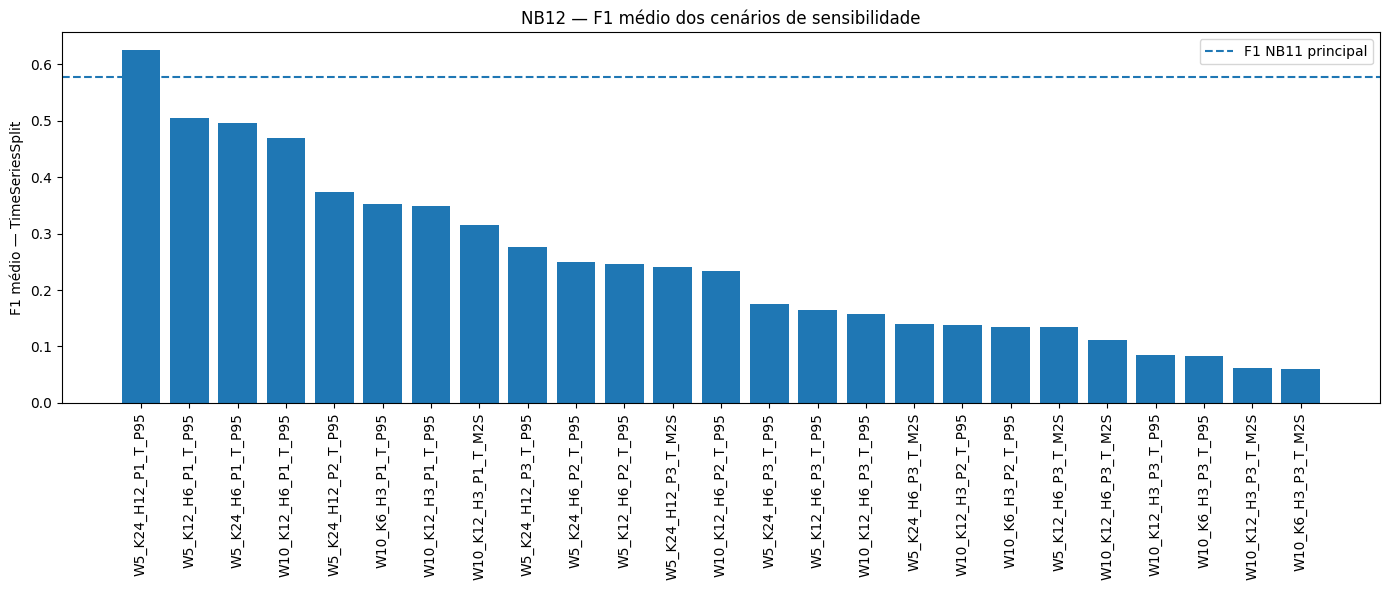

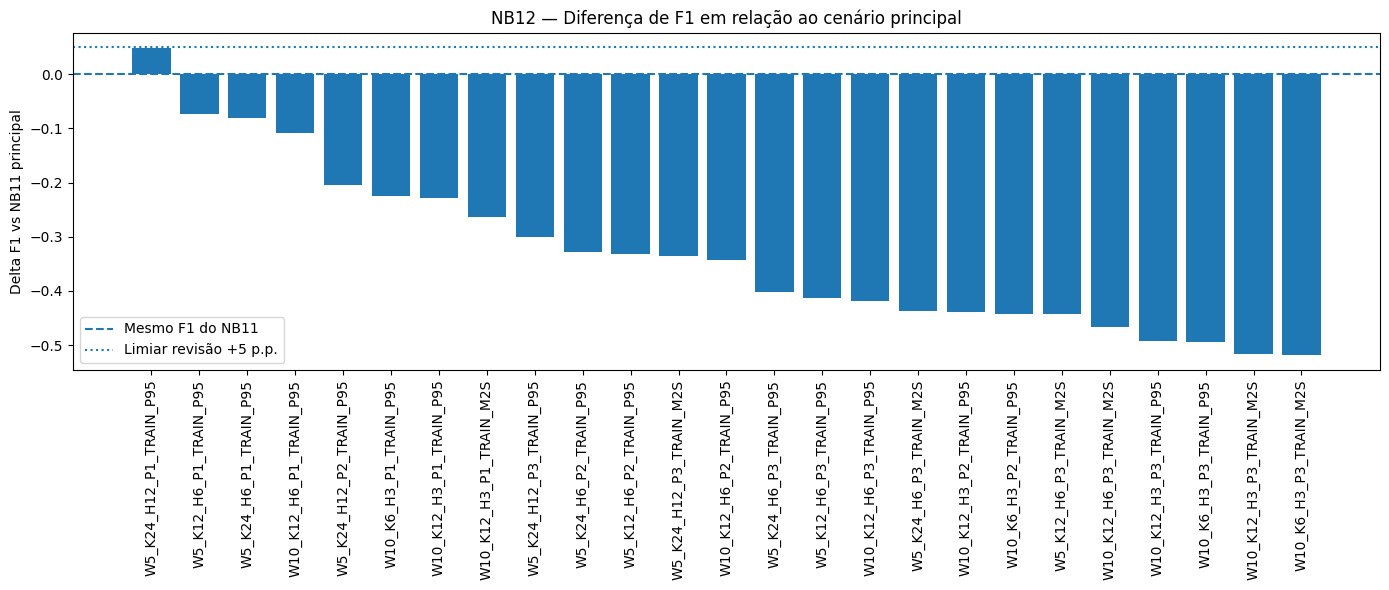

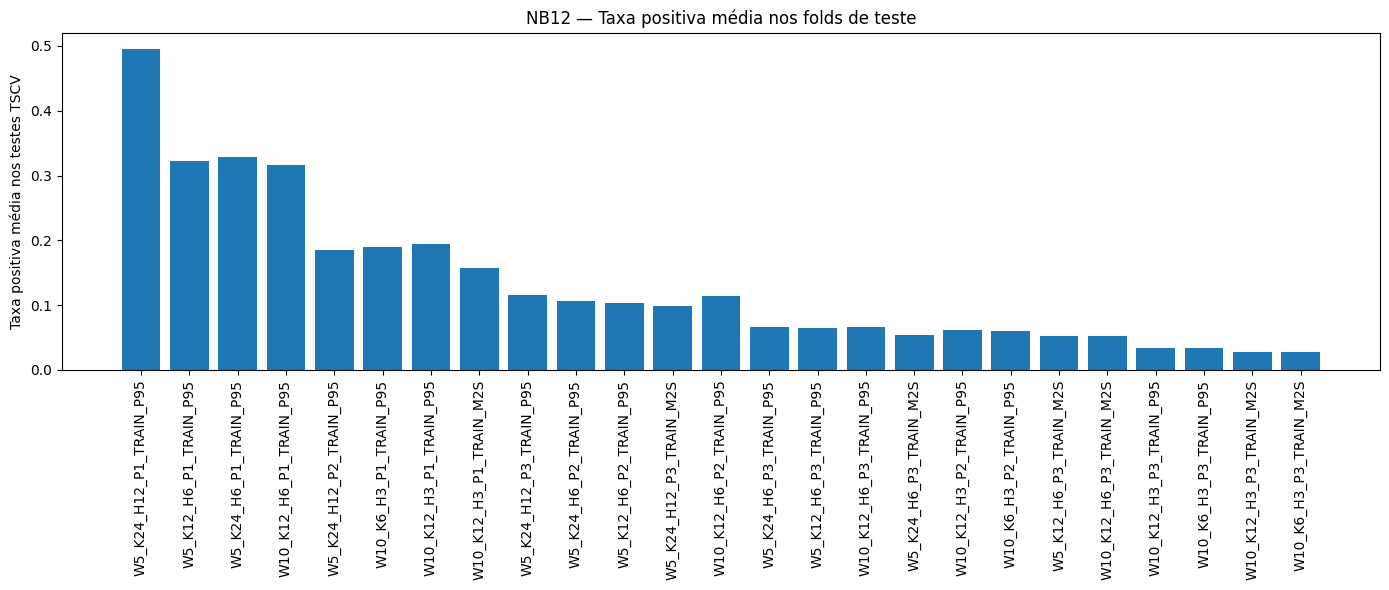

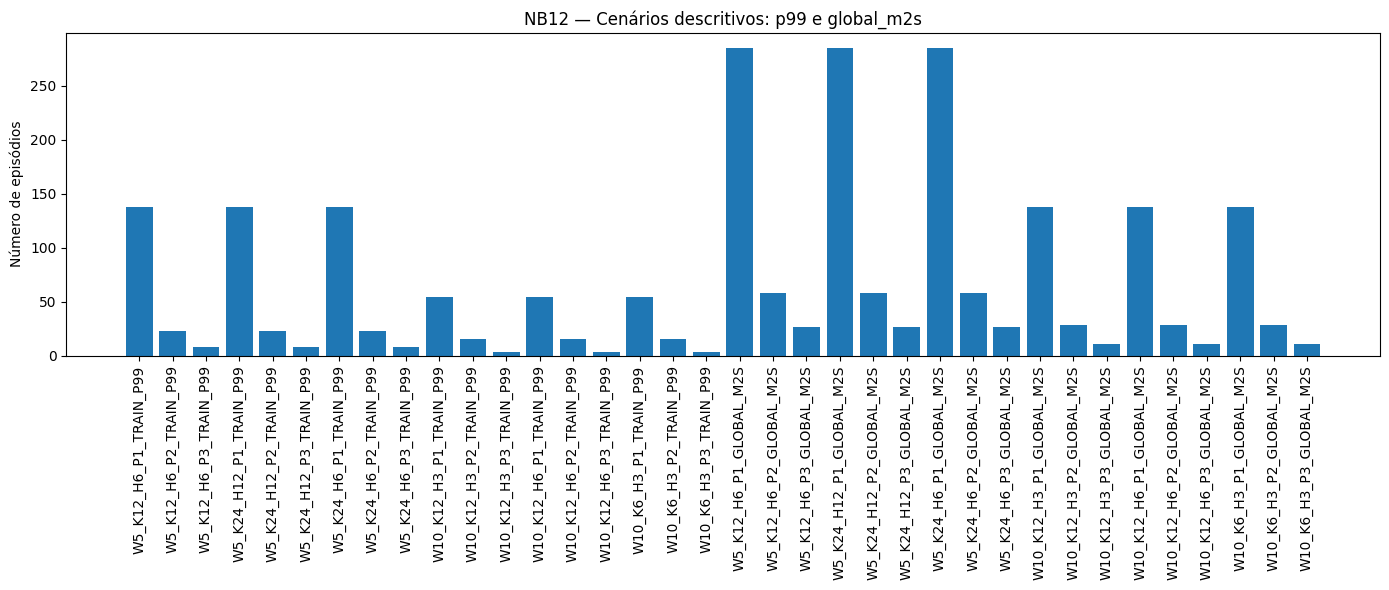


Resumo NB12:
{
  "notebook": "NB12",
  "title": "Sensibilidade Compacta e Robustez das Escolhas",
  "executed_at": "2026-07-23 19:42:57",
  "objective": "Verificar se as decisões centrais do NB10/NB11 permanecem estáveis sob variações moderadas de limiar, persistência e referência histórica.",
  "nb11_reference": {
    "scenario_label": "W5_K24_H12_P1_TRAIN_M2S",
    "model": "logistic_regression",
    "feature_set": "temporal_core",
    "f1_tscv_mean": 0.5772970553519514,
    "features": [
      "fail_rate",
      "n_events",
      "n_failed",
      "n_machines",
      "n_collections",
      "event_LOST_count",
      "lag_1",
      "lag_2",
      "lag_3",
      "rolling_mean_1h",
      "rolling_std_1h",
      "pct_change",
      "zscore_expanding"
    ]
  },
  "nb11_baseline_context": {
    "source": "11_baselines_summary.csv and 11_nb11_summary.json",
    "purpose_in_nb12": "Registrar que o NB11 passou a incluir EWMA causal como baseline temporal suavizado; não executar tuning de al

In [ ]:
# ============================================================
# NB12 — Sensibilidade Compacta e Robustez das Escolhas
# Pipeline PPCOMP/DM — Dissertação de Mestrado
#
# Objetivo:
#   Verificar se as decisões centrais do NB10/NB11 permanecem
#   estáveis sob variações moderadas de limiar, persistência e
#   referência histórica.
#
# Princípios:
#   1. Não repetir o NB11.
#   2. Não abrir novo grid search amplo.
#   3. Executar somente o modelo vencedor do NB11.
#   4. Tratar train_p99 apenas como severidade extrema descritiva.
#   5. Manter global_m2s apenas como referência histórica.
#   6. Avaliar a cláusula de revisão train_p95 > train_m2s + 5 p.p.
# ============================================================


# ============================================================
# 0. Imports e configuração geral
# ============================================================

import os
import re
import json
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS_TSCV = 5
FIXED_TRAIN_FRAC = 0.80
DEFAULT_THRESHOLD = 0.50
REVIEW_DELTA_F1 = 0.05

RAW_CORE = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_LOST_count",
]

TEMPORAL_CORE = RAW_CORE + [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

PROVENANCE_ONLY_COLUMNS = {"event_FAIL_count"}

BASE_FORBIDDEN_PREDICTORS = {
    "anticipation_target",
    "bucket_id",
    "bucket_start_us",
    "eligible_supervised",
    "episode_id",
    "event_FAIL_count",
    "has_complete_horizon",
    "has_complete_horizon_nb11",
    "is_critical",
    "scenario_label",
    "state",
    "target",
    "target_binary",
    "will_enter_during_h",
    "y",
    "y_anticipation",
    "y_binary",
    "y_nb11",
}

assert len(RAW_CORE) == 6
assert len(TEMPORAL_CORE) == 13
assert len(RAW_CORE) == len(set(RAW_CORE))
assert len(TEMPORAL_CORE) == len(set(TEMPORAL_CORE))
assert "event_FAIL_count" not in RAW_CORE
assert "event_FAIL_count" not in TEMPORAL_CORE

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("NB12 iniciado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


# ============================================================
# 1. Paths do projeto
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    BASE_DIR = Path("/content/drive/MyDrive/Mestrado")
else:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "02-datasets"
FEATURES_DIR = DATA_DIR / "03-features"
MODELS_DIR = BASE_DIR / "03-models"
REPORTS_DIR = BASE_DIR / "04-reports"
NB11_DIR = REPORTS_DIR
NB12_DIR = REPORTS_DIR
NB11_LEGACY_DIR = REPORTS_DIR / "nb11"
NB12_LEGACY_DIR = REPORTS_DIR / "nb12"
FIGURES_DIR = REPORTS_DIR / "figures_nb12"

for p in [FEATURES_DIR, MODELS_DIR, REPORTS_DIR, NB12_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Backup leve dos artefatos anteriores do NB12.
# Os artefatos oficiais novos serão gravados diretamente em 04-reports/.
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")
BACKUP_DIR = REPORTS_DIR / "_backup_previous_artifacts" / RUN_TIMESTAMP_FILE / "nb12"
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

def backup_existing_nb12_artifacts():
    import shutil

    patterns = [
        "12_*.csv",
        "12_*.json",
        "12_*.parquet",
        "12_*.txt",
    ]

    copied = []

    for pattern in patterns:
        for path in REPORTS_DIR.glob(pattern):
            if path.is_file():
                target = BACKUP_DIR / path.name
                shutil.copy2(path, target)
                copied.append(str(path))

    if NB12_LEGACY_DIR.exists() and NB12_LEGACY_DIR.is_dir():
        target_dir = BACKUP_DIR / "legacy_nb12"
        if not target_dir.exists():
            shutil.copytree(NB12_LEGACY_DIR, target_dir)
            copied.append(str(NB12_LEGACY_DIR))

    if copied:
        print(f"[BACKUP NB12] Artefatos anteriores copiados para: {BACKUP_DIR}")
    else:
        print("[BACKUP NB12] Nenhum artefato anterior encontrado para backup.")

backup_existing_nb12_artifacts()


print("BASE_DIR    :", BASE_DIR)
print("REPORTS_DIR :", REPORTS_DIR)
print("NB11_DIR    :", NB11_DIR)
print("NB12_DIR    :", NB12_DIR)
print("FIGURES_DIR :", FIGURES_DIR)


# ============================================================
# 2. Utilidades de arquivo
# ============================================================

def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def find_file(filename, search_roots, required=True):
    """
    Procura arquivo em locais esperados e, se necessário, recursivamente.
    """
    for root in search_roots:
        candidate = Path(root) / filename
        if candidate.exists():
            return candidate

    for root in search_roots:
        root = Path(root)
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                # Preferir arquivos mais recentes.
                matches = sorted(matches, key=lambda p: p.stat().st_mtime, reverse=True)
                return matches[0]

    if required:
        raise FileNotFoundError(f"Arquivo não encontrado: {filename}")

    return None


search_roots = [
    REPORTS_DIR,
    NB11_DIR,
    NB12_DIR,
    BASE_DIR,
]

# Entradas NB10
PATH_DECISIONS = find_file("10_scenario_decisions.csv", search_roots, required=True)
PATH_STATES = find_file("10_scenario_series_states.parquet", search_roots, required=True)
PATH_EPISODES = find_file("10_scenario_episodes.parquet", search_roots, required=True)

PATH_EPISODE_SUMMARY = find_file("10_scenario_episode_summary.csv", search_roots, required=False)
PATH_LABEL_IMPACT = find_file("10_scenario_label_impact.csv", search_roots, required=False)
PATH_THRESHOLDS = find_file("10_scenario_thresholds_summary.csv", search_roots, required=False)
PATH_NB10_JSON = find_file("10_scenario_diagnostics_summary.json", search_roots, required=False)

# Entradas NB11
PATH_WINNER = find_file("11_winner_model.json", [NB11_DIR, NB11_LEGACY_DIR, REPORTS_DIR, BASE_DIR], required=True)
PATH_NB11_SUMMARY = find_file("11_nb11_summary.json", [NB11_DIR, NB11_LEGACY_DIR, REPORTS_DIR, BASE_DIR], required=False)
PATH_NB11_METRICS_SUMMARY = find_file("11_metrics_summary.csv", [NB11_DIR, NB11_LEGACY_DIR, REPORTS_DIR, BASE_DIR], required=False)
PATH_NB11_BASELINES_SUMMARY = find_file("11_baselines_summary.csv", [NB11_DIR, NB11_LEGACY_DIR, REPORTS_DIR, BASE_DIR], required=False)
PATH_NB11_FEATURE_SETS = find_file("11_feature_sets.json", [NB11_DIR, NB11_LEGACY_DIR, REPORTS_DIR, BASE_DIR], required=True)

print("Entradas localizadas:")
print("  10 decisions :", PATH_DECISIONS)
print("  10 states    :", PATH_STATES)
print("  10 episodes  :", PATH_EPISODES)
print("  11 winner    :", PATH_WINNER)
print("  11 baselines :", PATH_NB11_BASELINES_SUMMARY if PATH_NB11_BASELINES_SUMMARY else "não localizado")
print("  11 feature sets:", PATH_NB11_FEATURE_SETS)


# ============================================================
# 3. Carregamento dos artefatos
# ============================================================

df_decisions = pd.read_csv(PATH_DECISIONS)
df_states_all = pd.read_parquet(PATH_STATES)
df_episodes_all = pd.read_parquet(PATH_EPISODES)

df_episode_summary = pd.read_csv(PATH_EPISODE_SUMMARY) if PATH_EPISODE_SUMMARY else pd.DataFrame()
df_label_impact = pd.read_csv(PATH_LABEL_IMPACT) if PATH_LABEL_IMPACT else pd.DataFrame()
df_thresholds = pd.read_csv(PATH_THRESHOLDS) if PATH_THRESHOLDS else pd.DataFrame()

winner = read_json(PATH_WINNER)
nb11_summary = read_json(PATH_NB11_SUMMARY) if PATH_NB11_SUMMARY else {}
df_nb11_metrics_summary = pd.read_csv(PATH_NB11_METRICS_SUMMARY) if PATH_NB11_METRICS_SUMMARY else pd.DataFrame()
df_nb11_baselines_summary = pd.read_csv(PATH_NB11_BASELINES_SUMMARY) if PATH_NB11_BASELINES_SUMMARY else pd.DataFrame()
nb11_feature_sets = read_json(PATH_NB11_FEATURE_SETS)

print("df_decisions:", df_decisions.shape)
print("df_states_all:", df_states_all.shape)
print("df_episodes_all:", df_episodes_all.shape)
print("df_nb11_baselines_summary:", df_nb11_baselines_summary.shape)
print("winner:", winner)


# ============================================================
# 4. Funções de inferência de colunas e parsing de cenário
# ============================================================

def infer_scenario_column(df: pd.DataFrame):
    candidates = [
        "scenario_label",
        "scenario",
        "scenario_id",
        "config_label",
        "label",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError("Não foi possível identificar coluna de cenário.")


def infer_category_column(df: pd.DataFrame):
    candidates = [
        "decision",
        "category",
        "decision_category",
        "promotion",
        "status",
        "nb11_decision",
        "action",
    ]

    for c in candidates:
        if c in df.columns:
            vals = df[c].astype(str).str.lower()
            if vals.str.contains("sensitivity_only|advance_to_nb11|historical_reference|do_not_advance").any():
                return c

    for c in df.columns:
        if df[c].dtype == "object":
            vals = df[c].astype(str).str.lower()
            if vals.str.contains("sensitivity_only|advance_to_nb11|historical_reference|do_not_advance").any():
                return c

    raise ValueError("Não foi possível identificar coluna de decisão/categoria no NB10.")


def infer_episode_columns(df_episodes: pd.DataFrame):
    start_candidates = [
        "start_bucket_id",
        "episode_start_bucket_id",
        "start_bucket",
        "bucket_start",
        "start",
    ]
    end_candidates = [
        "end_bucket_id",
        "episode_end_bucket_id",
        "end_bucket",
        "bucket_end",
        "end",
    ]

    start_col = next((c for c in start_candidates if c in df_episodes.columns), None)
    end_col = next((c for c in end_candidates if c in df_episodes.columns), None)

    if start_col is None or end_col is None:
        raise ValueError("Colunas de início/fim de episódio não identificadas.")

    return start_col, end_col


scenario_col_decisions = infer_scenario_column(df_decisions)
scenario_col_states = infer_scenario_column(df_states_all)
scenario_col_episodes = infer_scenario_column(df_episodes_all)
decision_col = infer_category_column(df_decisions)
episode_start_col, episode_end_col = infer_episode_columns(df_episodes_all)

print("scenario_col_decisions:", scenario_col_decisions)
print("scenario_col_states   :", scenario_col_states)
print("scenario_col_episodes :", scenario_col_episodes)
print("decision_col          :", decision_col)
print("episode_start_col     :", episode_start_col)
print("episode_end_col       :", episode_end_col)


def parse_scenario_label(label):
    """
    Interpreta labels no padrão:
    W5_K24_H12_P1_TRAIN_M2S
    W5_K24_H12_P1_TRAIN_P95
    W5_K24_H12_P1_GLOBAL_M2S
    etc.
    """
    label = str(label)

    pattern = r"W(?P<W>\d+)_K(?P<K>\d+)_H(?P<H>\d+)_P(?P<P>\d+)_(?P<threshold>.+)"
    m = re.match(pattern, label)

    if not m:
        return {
            "scenario_label": label,
            "W": np.nan,
            "K": np.nan,
            "H": np.nan,
            "P": np.nan,
            "threshold_kind": "unknown",
            "threshold_family": "unknown",
        }

    threshold_kind = m.group("threshold").upper()
    threshold_family = threshold_kind.lower()

    return {
        "scenario_label": label,
        "W": int(m.group("W")),
        "K": int(m.group("K")),
        "H": int(m.group("H")),
        "P": int(m.group("P")),
        "threshold_kind": threshold_kind,
        "threshold_family": threshold_family,
    }


def enrich_with_parsed_scenario(df, scenario_col):
    parsed = df[scenario_col].apply(parse_scenario_label).apply(pd.Series)
    out = df.copy()

    for c in parsed.columns:
        if c not in out.columns:
            out[c] = parsed[c]

    return out


df_decisions = enrich_with_parsed_scenario(df_decisions, scenario_col_decisions)
df_states_all = enrich_with_parsed_scenario(df_states_all, scenario_col_states)
df_episodes_all = enrich_with_parsed_scenario(df_episodes_all, scenario_col_episodes)

if not df_episode_summary.empty:
    try:
        episode_summary_scen_col = infer_scenario_column(df_episode_summary)
        df_episode_summary = enrich_with_parsed_scenario(df_episode_summary, episode_summary_scen_col)
    except Exception:
        pass

if not df_label_impact.empty:
    try:
        label_impact_scen_col = infer_scenario_column(df_label_impact)
        df_label_impact = enrich_with_parsed_scenario(df_label_impact, label_impact_scen_col)
    except Exception:
        pass


# ============================================================
# 5. Métricas e funções auxiliares
# ============================================================

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def safe_brier(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(y_true) == 0:
        return np.nan
    return brier_score_loss(y_true, np.clip(y_score, 0, 1))


def binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    if len(y_true) == 0:
        return {
            "n": 0,
            "positive_rate": np.nan,
            "threshold": threshold,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "roc_auc": np.nan,
            "average_precision": np.nan,
            "brier": np.nan,
            "tn": 0,
            "fp": 0,
            "fn": 0,
            "tp": 0,
        }

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "n": int(len(y_true)),
        "positive_rate": float(np.mean(y_true)),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(safe_auc(y_true, y_score)) if not np.isnan(safe_auc(y_true, y_score)) else np.nan,
        "average_precision": float(safe_ap(y_true, y_score)) if not np.isnan(safe_ap(y_true, y_score)) else np.nan,
        "brier": float(safe_brier(y_true, y_score)) if not np.isnan(safe_brier(y_true, y_score)) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def false_alerts_per_day(y_true, y_score, window_minutes, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    false_alerts = int(((y_pred == 1) & (y_true == 0)).sum())
    total_days = (len(y_true) * window_minutes) / (60 * 24)

    return {
        "false_alerts": false_alerts,
        "false_alerts_per_day": float(false_alerts / total_days) if total_days > 0 else np.nan,
    }


# ============================================================
# 6. Features temporais causais
# ============================================================

def add_causal_temporal_features(df: pd.DataFrame, window_minutes: int):
    """
    Reconstrói features temporais causais a partir de fail_rate.
    """
    if "fail_rate" not in df.columns:
        raise ValueError("fail_rate é necessária para criar features temporais causais.")

    df = df.sort_values("bucket_id").copy()

    df["lag_1"] = df["fail_rate"].shift(1)
    df["lag_2"] = df["fail_rate"].shift(2)
    df["lag_3"] = df["fail_rate"].shift(3)

    rolling_window = max(int(round(60 / window_minutes)), 1)

    df["rolling_mean_1h"] = (
        df["fail_rate"]
        .shift(1)
        .rolling(window=rolling_window, min_periods=1)
        .mean()
    )

    df["rolling_std_1h"] = (
        df["fail_rate"]
        .shift(1)
        .rolling(window=rolling_window, min_periods=2)
        .std(ddof=0)
    )

    previous = df["fail_rate"].shift(1)
    df["pct_change"] = (df["fail_rate"] - previous) / previous.replace(0, np.nan)

    expanding_mean = df["fail_rate"].shift(1).expanding(min_periods=2).mean()
    expanding_std = df["fail_rate"].shift(1).expanding(min_periods=2).std(ddof=0)

    df["zscore_expanding"] = (
        (df["fail_rate"] - expanding_mean) / expanding_std.replace(0, np.nan)
    )

    temporal_cols = [
        "lag_1",
        "lag_2",
        "lag_3",
        "rolling_mean_1h",
        "rolling_std_1h",
        "pct_change",
        "zscore_expanding",
    ]

    df[temporal_cols] = (
        df[temporal_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    return df


# ============================================================
# 7. Alvo supervisionado
# ============================================================

def get_h_windows_from_label(label, fallback=12):
    parsed = parse_scenario_label(label)
    if pd.isna(parsed["H"]):
        return fallback
    return int(parsed["H"])


def get_window_minutes_from_label(label, fallback=5):
    parsed = parse_scenario_label(label)
    if pd.isna(parsed["W"]):
        return fallback
    return int(parsed["W"])


def ensure_target_column(df: pd.DataFrame, scenario_label: str):
    """
    Garante y_nb12.
    Prioriza alvo já existente; caso contrário, reconstrói pela presença futura de DURING.
    """
    df = df.copy()

    target_candidates = [
        "y",
        "target",
        "target_binary",
        "y_binary",
        "y_anticipation",
        "anticipation_target",
        "will_enter_during_h",
        "y_nb11",
    ]

    for c in target_candidates:
        if c in df.columns:
            df["y_nb12"] = df[c].astype(int)

            if "state" in df.columns:
                df = df[df["state"].astype(str).isin(["NORMAL", "BEFORE"])].copy()

            for hcol in ["has_complete_horizon", "complete_horizon", "has_complete_horizon_nb11"]:
                if hcol in df.columns:
                    df = df[df[hcol].astype(bool)].copy()

            return df

    if "state" not in df.columns:
        raise ValueError("Nenhum alvo encontrado e coluna state ausente.")

    h_windows = get_h_windows_from_label(scenario_label, fallback=12)

    df = df.sort_values("bucket_id").reset_index(drop=True).copy()
    states = df["state"].astype(str).values
    during = (states == "DURING")

    y = np.zeros(len(df), dtype=int)

    for step in range(1, h_windows + 1):
        shifted = np.zeros(len(df), dtype=bool)
        shifted[:-step] = during[step:]
        y = np.logical_or(y, shifted)

    df["y_nb12"] = y.astype(int)

    df["has_complete_horizon_nb12"] = False
    if len(df) > h_windows:
        df.loc[: len(df) - h_windows - 1, "has_complete_horizon_nb12"] = True

    df = df[
        df["state"].astype(str).isin(["NORMAL", "BEFORE"])
        & df["has_complete_horizon_nb12"]
    ].copy()

    return df


# ============================================================
# 8. Modelo vencedor do NB11
# ============================================================

def make_estimator_from_winner(winner_dict):
    model_name = str(winner_dict.get("model", "logistic_regression"))

    if model_name == "logistic_regression":
        return Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    solver="lbfgs",
                )),
            ]
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample",
        )

    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=RANDOM_STATE,
        )

    raise ValueError(f"Modelo vencedor não suportado no NB12: {model_name}")


def compute_sample_weight_balanced(y):
    y = np.asarray(y).astype(int)
    n = len(y)
    classes, counts = np.unique(y, return_counts=True)

    weights = np.ones(n, dtype=float)

    for cls, cnt in zip(classes, counts):
        weights[y == cls] = n / (len(classes) * cnt)

    return weights


def fit_winner_model(estimator, model_name, X_train, y_train):
    est = clone(estimator)

    if model_name == "hist_gradient_boosting":
        sw = compute_sample_weight_balanced(y_train)
        est.fit(X_train, y_train, sample_weight=sw)
    else:
        est.fit(X_train, y_train)

    return est


def predict_score(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]

    if hasattr(estimator, "decision_function"):
        raw = estimator.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))

    return estimator.predict(X).astype(float)


def series_equal_with_na(left: pd.Series, right: pd.Series) -> bool:
    equal = left.eq(right) | (left.isna() & right.isna())
    return bool(equal.all())


def validate_failure_count_provenance(df: pd.DataFrame, context: str):
    required = {"n_failed", "event_FAIL_count"}
    missing = sorted(required - set(df.columns))
    if missing:
        raise AssertionError(
            f"{context}: colunas de proveniência ausentes: {missing}"
        )

    if not series_equal_with_na(df["n_failed"], df["event_FAIL_count"]):
        mismatch = ~(
            df["n_failed"].eq(df["event_FAIL_count"])
            | (df["n_failed"].isna() & df["event_FAIL_count"].isna())
        )
        raise AssertionError(
            f"{context}: n_failed difere de event_FAIL_count em "
            f"{int(mismatch.sum())} linha(s)."
        )


def validate_fail_rate_semantics(df: pd.DataFrame, context: str):
    required = {"fail_rate", "n_events", "n_failed"}
    missing = sorted(required - set(df.columns))
    if missing:
        raise AssertionError(
            f"{context}: colunas para validar fail_rate ausentes: {missing}"
        )

    denominator = pd.to_numeric(df["n_events"], errors="coerce")
    numerator = pd.to_numeric(df["n_failed"], errors="coerce")
    observed = pd.to_numeric(df["fail_rate"], errors="coerce")

    expected = pd.Series(
        np.where(denominator > 0, numerator / denominator, 0.0),
        index=df.index,
        dtype=float,
    )

    valid = np.isclose(
        observed.to_numpy(dtype=float),
        expected.to_numpy(dtype=float),
        rtol=1e-7,
        atol=1e-9,
        equal_nan=True,
    )

    if not bool(valid.all()):
        raise AssertionError(
            f"{context}: fail_rate diverge de n_failed/n_events em "
            f"{int((~valid).sum())} linha(s)."
        )


def validate_nb11_feature_contract(payload: dict):
    payload_raw = list(payload.get("raw_core", []))
    payload_temporal = list(payload.get("temporal_core", []))

    if payload_raw != RAW_CORE:
        raise AssertionError(
            "11_feature_sets.json não corresponde ao contrato normativo raw_core."
        )

    if payload_temporal != TEMPORAL_CORE:
        raise AssertionError(
            "11_feature_sets.json não corresponde ao contrato normativo temporal_core."
        )

    expected = payload.get("expected_cardinality", {})
    if int(expected.get("raw_core", -1)) != 6:
        raise AssertionError("Cardinalidade raw_core diferente de 6 no NB11.")
    if int(expected.get("temporal_core", -1)) != 13:
        raise AssertionError("Cardinalidade temporal_core diferente de 13 no NB11.")


def validate_active_feature_list(
    feature_set_name: str,
    features: list,
    contract_payload: dict,
):
    if not features:
        raise AssertionError("Lista de atributos do vencedor está vazia.")

    if len(features) != len(set(features)):
        raise AssertionError("Lista de atributos do vencedor contém nomes repetidos.")

    forbidden = set(BASE_FORBIDDEN_PREDICTORS)
    forbidden.update(contract_payload.get("forbidden_predictors", []))

    overlap = sorted(set(features) & forbidden)
    if overlap:
        raise AssertionError(
            f"Atributos proibidos no vetor preditivo: {overlap}"
        )

    patterns = [
        str(pattern).lower()
        for pattern in contract_payload.get(
            "forbidden_feature_patterns",
            [],
        )
    ]
    pattern_hits = sorted({
        feature
        for feature in features
        if any(pattern in feature.lower() for pattern in patterns)
    })

    if pattern_hits:
        raise AssertionError(
            "Atributos incompatíveis com os padrões de proteção do NB11: "
            f"{pattern_hits}"
        )

    if "event_FAIL_count" in features:
        raise AssertionError(
            "event_FAIL_count não pode integrar o vetor preditivo."
        )

    if feature_set_name == "raw_core":
        if features != RAW_CORE or len(features) != 6:
            raise AssertionError(
                "O vencedor identificado como raw_core não respeita o contrato de 6 atributos."
            )

    if feature_set_name == "temporal_core":
        if features != TEMPORAL_CORE or len(features) != 13:
            raise AssertionError(
                "O vencedor identificado como temporal_core não respeita o contrato de 13 atributos."
            )


def exact_duplicate_pairs(df: pd.DataFrame, features: list):
    pairs = []

    for idx, left_name in enumerate(features):
        for right_name in features[idx + 1:]:
            left = df[left_name]
            right = df[right_name]
            equal = left.eq(right) | (left.isna() & right.isna())

            if bool(equal.all()):
                pairs.append((left_name, right_name))

    return pairs


validate_nb11_feature_contract(nb11_feature_sets)
validate_failure_count_provenance(df_states_all, "10_scenario_series_states")
validate_fail_rate_semantics(df_states_all, "10_scenario_series_states")


winner_model_name = str(winner.get("model", "logistic_regression"))
winner_feature_set = str(winner.get("feature_set", "temporal_core"))
winner_features = list(winner.get("features", []))

if not winner_features:
    raise ValueError("Arquivo 11_winner_model.json não contém lista de features.")

validate_active_feature_list(
    winner_feature_set,
    winner_features,
    nb11_feature_sets,
)

winner_estimator = make_estimator_from_winner(winner)

nb11_main_f1 = float(winner.get("f1_tscv_mean", np.nan))
nb11_main_scenario = str(winner.get("scenario_label"))
nb11_main_parsed = parse_scenario_label(nb11_main_scenario)

print("Modelo vencedor NB11:", winner_model_name)
print("Feature set vencedor:", winner_feature_set)
print("Cenário principal NB11:", nb11_main_scenario)
print("F1 TSCV referência NB11:", nb11_main_f1)
print("Features:", winner_features)


# Contexto descritivo dos baselines do NB11, incluindo EWMA causal.
# O NB12 não usa o EWMA como novo eixo de sensibilidade nem faz tuning de alpha.
# Este bloco apenas registra a comparação herdada do NB11 para fins de rastreabilidade narrativa.
def build_nb11_baseline_context(df_baselines_summary, nb11_summary, main_scenario):
    baseline_configuration = nb11_summary.get("baseline_configuration", {}) if isinstance(nb11_summary, dict) else {}
    best_baseline_tscv = nb11_summary.get("best_baseline_tscv", {}) if isinstance(nb11_summary, dict) else {}

    context = {
        "source": "11_baselines_summary.csv and 11_nb11_summary.json",
        "purpose_in_nb12": (
            "Registrar que o NB11 passou a incluir EWMA causal como baseline temporal suavizado; "
            "não executar tuning de alpha nem transformar EWMA em eixo de sensibilidade do NB12."
        ),
        "baseline_configuration": baseline_configuration,
        "best_baseline_tscv": best_baseline_tscv,
        "ewma_tscv": None,
        "ewma_relative_position": "not_available",
    }

    if df_baselines_summary is None or df_baselines_summary.empty:
        context["ewma_relative_position"] = "11_baselines_summary_unavailable"
        return context

    df = df_baselines_summary.copy()

    required_cols = {"scenario_label", "baseline", "validation"}
    if not required_cols.issubset(df.columns):
        context["ewma_relative_position"] = "required_columns_unavailable"
        return context

    tscv = df[
        (df["scenario_label"].astype(str) == str(main_scenario))
        & (df["validation"].astype(str).str.lower() == "timeseries_split")
    ].copy()

    if tscv.empty:
        context["ewma_relative_position"] = "main_scenario_tscv_unavailable"
        return context

    ewma = tscv[
        tscv["baseline"].astype(str).str.contains("ewma", case=False, na=False)
    ].copy()

    if not ewma.empty:
        r = ewma.sort_values("f1_mean", ascending=False).iloc[0]
        context["ewma_tscv"] = {
            "scenario_label": str(r["scenario_label"]),
            "baseline": str(r["baseline"]),
            "f1_mean": float(r["f1_mean"]) if "f1_mean" in r and not pd.isna(r["f1_mean"]) else np.nan,
            "recall_mean": float(r["recall_mean"]) if "recall_mean" in r and not pd.isna(r["recall_mean"]) else np.nan,
            "precision_mean": float(r["precision_mean"]) if "precision_mean" in r and not pd.isna(r["precision_mean"]) else np.nan,
            "roc_auc_mean": float(r["roc_auc_mean"]) if "roc_auc_mean" in r and not pd.isna(r["roc_auc_mean"]) else np.nan,
            "average_precision_mean": float(r["average_precision_mean"]) if "average_precision_mean" in r and not pd.isna(r["average_precision_mean"]) else np.nan,
            "brier_mean": float(r["brier_mean"]) if "brier_mean" in r and not pd.isna(r["brier_mean"]) else np.nan,
            "false_alerts_per_day_mean": (
                float(r["false_alerts_per_day_mean"])
                if "false_alerts_per_day_mean" in r and not pd.isna(r["false_alerts_per_day_mean"])
                else np.nan
            ),
        }

        best_f1 = best_baseline_tscv.get("f1_mean", np.nan) if isinstance(best_baseline_tscv, dict) else np.nan
        ewma_f1 = context["ewma_tscv"]["f1_mean"]

        if pd.notna(best_f1) and pd.notna(ewma_f1):
            if ewma_f1 >= best_f1:
                context["ewma_relative_position"] = "ewma_matches_or_exceeds_best_baseline"
            elif (best_f1 - ewma_f1) <= 0.02:
                context["ewma_relative_position"] = "ewma_close_to_best_baseline"
            else:
                context["ewma_relative_position"] = "ewma_below_best_baseline"
        else:
            context["ewma_relative_position"] = "ewma_available_without_comparable_best_f1"
    else:
        context["ewma_relative_position"] = "ewma_row_unavailable_for_main_scenario"

    return context


nb11_baseline_context = build_nb11_baseline_context(
    df_baselines_summary=df_nb11_baselines_summary,
    nb11_summary=nb11_summary,
    main_scenario=nb11_main_scenario,
)

print("Contexto dos baselines NB11 para NB12:")
print(json.dumps(nb11_baseline_context, ensure_ascii=False, indent=2))


# ============================================================
# 9. Preparação de um cenário
# ============================================================

def prepare_scenario_dataframe(scenario_label):
    df = df_states_all[
        df_states_all[scenario_col_states].astype(str) == str(scenario_label)
    ].copy()

    if df.empty:
        raise ValueError(f"Nenhuma linha encontrada em states para {scenario_label}")

    if "bucket_id" not in df.columns:
        raise ValueError("Coluna bucket_id obrigatória ausente.")

    window_minutes = get_window_minutes_from_label(scenario_label)
    h_windows = get_h_windows_from_label(scenario_label)

    df = df.sort_values("bucket_id").reset_index(drop=True)

    validate_failure_count_provenance(df, f"cenário {scenario_label}")
    validate_fail_rate_semantics(df, f"cenário {scenario_label}")

    # Reconstrói features temporais para garantir compatibilidade com temporal_core.
    df = add_causal_temporal_features(df, window_minutes=window_minutes)

    # Garante alvo supervisionado.
    df = ensure_target_column(df, scenario_label=scenario_label)

    # Confere features necessárias.
    missing_features = [c for c in winner_features if c not in df.columns]

    if missing_features:
        raise ValueError(
            f"Cenário {scenario_label} sem features necessárias ao vencedor: {missing_features}"
        )

    df[winner_features] = (
        df[winner_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    return df, window_minutes, h_windows


# ============================================================
# 10. Seleção dos cenários do NB12
# ============================================================

df_decisions["decision_normalized"] = df_decisions[decision_col].astype(str).str.lower()
df_decisions["threshold_normalized"] = df_decisions["threshold_family"].astype(str).str.lower()

# Categorias de interesse.
df_sensitivity_only = df_decisions[
    df_decisions["decision_normalized"].str.contains("sensitivity_only", na=False)
].copy()

df_historical_reference = df_decisions[
    df_decisions["decision_normalized"].str.contains("historical_reference", na=False)
].copy()

# Cenários p99: apenas descritivos.
df_p99_candidates = df_decisions[
    df_decisions["threshold_normalized"].str.contains("p99", na=False)
].copy()

# Cenários global_m2s: referência histórica, sem execução do modelo.
df_global_candidates = df_decisions[
    df_decisions["threshold_normalized"].str.contains("global_m2s", na=False)
].copy()

# Elegíveis para modelo:
# sensitivity_only, exceto p99 e global.
df_model_candidates = df_sensitivity_only[
    ~df_sensitivity_only["threshold_normalized"].str.contains("p99", na=False)
    & ~df_sensitivity_only["threshold_normalized"].str.contains("global_m2s", na=False)
].copy()

# Remover duplicatas por cenário.
df_model_candidates = df_model_candidates.drop_duplicates(subset=[scenario_col_decisions])

model_candidate_labels = df_model_candidates[scenario_col_decisions].astype(str).tolist()
p99_labels = df_p99_candidates[scenario_col_decisions].astype(str).drop_duplicates().tolist()
global_labels = df_global_candidates[scenario_col_decisions].astype(str).drop_duplicates().tolist()

# Preflight de todos os dataframes efetivamente destinados à modelagem.
# Nenhum treinamento começa antes do PASS integral do contrato.
feature_duplicate_audit_records = []
feature_duplicate_failures = []

for scenario_label in model_candidate_labels:
    df_preflight, _, _ = prepare_scenario_dataframe(scenario_label)
    duplicate_pairs = exact_duplicate_pairs(df_preflight, winner_features)

    feature_duplicate_audit_records.append({
        "scenario_label": scenario_label,
        "feature_set": winner_feature_set,
        "n_features": int(len(winner_features)),
        "event_FAIL_count_in_predictors": bool(
            "event_FAIL_count" in winner_features
        ),
        "n_failed_event_FAIL_count_equal": True,
        "n_exact_duplicate_pairs": int(len(duplicate_pairs)),
        "duplicate_pairs": "|".join(
            f"{left}=={right}" for left, right in duplicate_pairs
        ),
        "status": "PASS" if not duplicate_pairs else "FAIL",
    })

    if duplicate_pairs:
        feature_duplicate_failures.append({
            "scenario_label": scenario_label,
            "duplicate_pairs": duplicate_pairs,
        })

df_feature_duplicate_audit = pd.DataFrame(feature_duplicate_audit_records)
df_feature_duplicate_audit.to_csv(
    NB12_DIR / "12_feature_duplicate_audit.csv",
    index=False,
)

if feature_duplicate_failures:
    raise AssertionError(
        "Duplicidade exata não justificada detectada antes do treinamento: "
        f"{feature_duplicate_failures}"
    )

print("\nCenários sensitivity_only:", len(df_sensitivity_only))
print("Cenários elegíveis para modelo NB12:", len(model_candidate_labels))
print("Cenários p99 descritivos:", len(p99_labels))
print("Cenários global_m2s referência:", len(global_labels))

display(df_model_candidates[[scenario_col_decisions, decision_col, "W", "K", "H", "P", "threshold_kind"]].head(30))


# ============================================================
# 11. Avaliação do modelo vencedor nos cenários elegíveis
# ============================================================

def evaluate_winner_on_scenario(scenario_label):
    print("\n" + "=" * 90)
    print("Avaliando cenário de sensibilidade:", scenario_label)
    print("=" * 90)

    df, window_minutes, h_windows = prepare_scenario_dataframe(scenario_label)

    y = df["y_nb12"].astype(int).values
    X = df[winner_features].values

    if len(np.unique(y)) < 2:
        raise ValueError(f"Cenário {scenario_label} possui apenas uma classe após filtros.")

    print("Linhas supervisionadas:", len(df))
    print("Taxa positiva:", round(float(y.mean()), 4))
    print("window_minutes:", window_minutes)
    print("h_windows:", h_windows)

    tscv = TimeSeriesSplit(n_splits=N_SPLITS_TSCV)

    tscv_records = []

    for fold_id, (tr_idx, te_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X[tr_idx], X[te_idx]
        y_train, y_test = y[tr_idx], y[te_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            continue

        est = fit_winner_model(
            estimator=winner_estimator,
            model_name=winner_model_name,
            X_train=X_train,
            y_train=y_train,
        )

        score_test = predict_score(est, X_test)

        metrics = binary_metrics(y_test, score_test, threshold=DEFAULT_THRESHOLD)
        fa = false_alerts_per_day(
            y_test,
            score_test,
            window_minutes=window_minutes,
            threshold=DEFAULT_THRESHOLD,
        )

        tscv_records.append({
            "scenario_label": scenario_label,
            "model": winner_model_name,
            "feature_set": winner_feature_set,
            "validation": "timeseries_split",
            "fold": int(fold_id),
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "train_positive_rate": float(y_train.mean()),
            "test_positive_rate": float(y_test.mean()),
            "window_minutes": int(window_minutes),
            "h_windows": int(h_windows),
            "n_features": int(len(winner_features)),
            "features": "|".join(winner_features),
            **parse_scenario_label(scenario_label),
            **metrics,
            **fa,
        })

    # Corte fixo 80/20 complementar.
    n = len(df)
    split_idx = int(np.floor(n * FIXED_TRAIN_FRAC))

    df_train = df.iloc[:split_idx].copy()
    df_test = df.iloc[split_idx:].copy()

    X_train = df_train[winner_features].values
    y_train = df_train["y_nb12"].astype(int).values

    X_test = df_test[winner_features].values
    y_test = df_test["y_nb12"].astype(int).values

    fixed_records = []
    score_rows = []

    if len(np.unique(y_train)) >= 2 and len(np.unique(y_test)) >= 2:
        est_fixed = fit_winner_model(
            estimator=winner_estimator,
            model_name=winner_model_name,
            X_train=X_train,
            y_train=y_train,
        )

        score_test = predict_score(est_fixed, X_test)

        metrics_fixed = binary_metrics(y_test, score_test, threshold=DEFAULT_THRESHOLD)
        fa_fixed = false_alerts_per_day(
            y_test,
            score_test,
            window_minutes=window_minutes,
            threshold=DEFAULT_THRESHOLD,
        )

        fixed_records.append({
            "scenario_label": scenario_label,
            "model": winner_model_name,
            "feature_set": winner_feature_set,
            "validation": "fixed_80_20",
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "train_positive_rate": float(y_train.mean()),
            "test_positive_rate": float(y_test.mean()),
            "window_minutes": int(window_minutes),
            "h_windows": int(h_windows),
            "n_features": int(len(winner_features)),
            "features": "|".join(winner_features),
            **parse_scenario_label(scenario_label),
            **metrics_fixed,
            **fa_fixed,
        })

        score_df = df_test[["bucket_id"]].copy()
        score_df["scenario_label"] = scenario_label
        score_df["model"] = winner_model_name
        score_df["feature_set"] = winner_feature_set
        score_df["validation"] = "fixed_80_20"
        score_df["y_true"] = y_test
        score_df["score_raw"] = score_test
        score_df["window_minutes"] = int(window_minutes)
        score_df["h_windows"] = int(h_windows)
        score_df["n_features"] = int(len(winner_features))
        score_df["features"] = "|".join(winner_features)

        score_rows.append(score_df)

    df_tscv = pd.DataFrame(tscv_records)
    df_fixed = pd.DataFrame(fixed_records)
    df_scores = pd.concat(score_rows, ignore_index=True) if score_rows else pd.DataFrame()

    return df_tscv, df_fixed, df_scores


all_tscv = []
all_fixed = []
all_scores = []
execution_errors = []

for scenario_label in model_candidate_labels:
    try:
        df_tscv, df_fixed, df_scores = evaluate_winner_on_scenario(scenario_label)

        all_tscv.append(df_tscv)
        all_fixed.append(df_fixed)
        all_scores.append(df_scores)

    except Exception as e:
        print("ERRO no cenário:", scenario_label, "->", str(e))
        execution_errors.append({
            "scenario_label": scenario_label,
            "error": str(e),
        })

df_tscv_all = pd.concat(all_tscv, ignore_index=True) if all_tscv else pd.DataFrame()
df_fixed_all = pd.concat(all_fixed, ignore_index=True) if all_fixed else pd.DataFrame()
df_scores_all = pd.concat(all_scores, ignore_index=True) if all_scores else pd.DataFrame()

print("\nExecução dos cenários de sensibilidade concluída.")
print("df_tscv_all :", df_tscv_all.shape)
print("df_fixed_all:", df_fixed_all.shape)
print("df_scores_all:", df_scores_all.shape)
print("erros:", len(execution_errors))


# ============================================================
# 12. Resumo dos cenários executados
# ============================================================

def summarize_tscv(df_tscv):
    if df_tscv.empty:
        return pd.DataFrame()

    rows = []

    for scenario_label, g in df_tscv.groupby("scenario_label"):
        parsed = parse_scenario_label(scenario_label)

        rows.append({
            "scenario_label": scenario_label,
            **parsed,
            "model": winner_model_name,
            "feature_set": winner_feature_set,
            "n_folds_valid": int(g["fold"].nunique()),
            "n_features": int(g["n_features"].iloc[0]),
            "features": str(g["features"].iloc[0]),

            "n_test_total": int(g["n_test"].sum()),
            "positive_rate_test_mean": float(g["test_positive_rate"].mean()),

            "accuracy_tscv_mean": float(g["accuracy"].mean()),
            "accuracy_tscv_std": float(g["accuracy"].std(ddof=0)),

            "precision_tscv_mean": float(g["precision"].mean()),
            "precision_tscv_std": float(g["precision"].std(ddof=0)),

            "recall_tscv_mean": float(g["recall"].mean()),
            "recall_tscv_std": float(g["recall"].std(ddof=0)),

            "f1_tscv_mean": float(g["f1"].mean()),
            "f1_tscv_std": float(g["f1"].std(ddof=0)),

            "roc_auc_tscv_mean": float(g["roc_auc"].mean()),
            "roc_auc_tscv_std": float(g["roc_auc"].std(ddof=0)),

            "average_precision_tscv_mean": float(g["average_precision"].mean()),
            "average_precision_tscv_std": float(g["average_precision"].std(ddof=0)),

            "brier_tscv_mean": float(g["brier"].mean()),
            "brier_tscv_std": float(g["brier"].std(ddof=0)),

            "false_alerts_per_day_tscv_mean": float(g["false_alerts_per_day"].mean()),
            "false_alerts_per_day_tscv_std": float(g["false_alerts_per_day"].std(ddof=0)),

            "delta_f1_vs_nb11_main": float(g["f1"].mean() - nb11_main_f1),
            "review_threshold_exceeded": bool((g["f1"].mean() - nb11_main_f1) > REVIEW_DELTA_F1),
        })

    return pd.DataFrame(rows)


df_sensitivity_summary = summarize_tscv(df_tscv_all)

if not df_sensitivity_summary.empty:
    df_sensitivity_summary = df_sensitivity_summary.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

display(df_sensitivity_summary.head(20))


# ============================================================
# 13. Descritivo p99 e referências históricas
# ============================================================

def descriptive_from_states_and_episodes(labels, descriptor_type):
    """
    Produz resumo descritivo sem execução de modelo.
    Usado para train_p99 e global_m2s.
    """
    rows = []

    for scenario_label in labels:
        df_s = df_states_all[
            df_states_all[scenario_col_states].astype(str) == str(scenario_label)
        ].copy()

        df_e = df_episodes_all[
            df_episodes_all[scenario_col_episodes].astype(str) == str(scenario_label)
        ].copy()

        if df_s.empty:
            continue

        parsed = parse_scenario_label(scenario_label)

        # Tenta reconstruir alvo supervisionado apenas para descritivo.
        try:
            df_prepared = df_s.sort_values("bucket_id").reset_index(drop=True)
            df_prepared = add_causal_temporal_features(
                df_prepared,
                window_minutes=int(parsed["W"]) if not pd.isna(parsed["W"]) else 5,
            )
            df_prepared = ensure_target_column(df_prepared, scenario_label)
            n_supervised = int(len(df_prepared))
            positive_rate = float(df_prepared["y_nb12"].mean()) if len(df_prepared) else np.nan
            positives = int(df_prepared["y_nb12"].sum()) if len(df_prepared) else 0
            negatives = int(len(df_prepared) - positives) if len(df_prepared) else 0
        except Exception:
            n_supervised = np.nan
            positive_rate = np.nan
            positives = np.nan
            negatives = np.nan

        # Janelas críticas: se houver state DURING, contar; se houver flag, usar flag.
        if "state" in df_s.columns:
            critical_windows = int((df_s["state"].astype(str) == "DURING").sum())
        elif "is_critical" in df_s.columns:
            critical_windows = int(df_s["is_critical"].sum())
        else:
            critical_windows = np.nan

        rows.append({
            "scenario_label": scenario_label,
            **parsed,
            "descriptor_type": descriptor_type,
            "n_windows_total": int(len(df_s)),
            "critical_windows_or_during_windows": critical_windows,
            "n_episodes": int(len(df_e)),
            "n_supervised_rows": n_supervised,
            "positives": positives,
            "negatives": negatives,
            "positive_rate": positive_rate,
            "nb12_policy": (
                "descriptive_only_no_model_execution"
                if descriptor_type == "train_p99_extreme_severity"
                else "historical_reference_no_model_execution"
            ),
        })

    return pd.DataFrame(rows)


df_p99_descriptive = descriptive_from_states_and_episodes(
    p99_labels,
    descriptor_type="train_p99_extreme_severity",
)

df_global_descriptive = descriptive_from_states_and_episodes(
    global_labels,
    descriptor_type="global_m2s_historical_reference",
)

df_descriptive = pd.concat(
    [df_p99_descriptive, df_global_descriptive],
    ignore_index=True,
)

display(df_descriptive.head(30))


# ============================================================
# 14. Cláusula de revisão metodológica — train_p95
# ============================================================

def is_same_temporal_structure_as_main(row):
    """
    Compara W, K, H e P com cenário principal do NB11.
    O limiar pode diferir.
    """
    return (
        int(row["W"]) == int(nb11_main_parsed["W"])
        and int(row["K"]) == int(nb11_main_parsed["K"])
        and int(row["H"]) == int(nb11_main_parsed["H"])
        and int(row["P"]) == int(nb11_main_parsed["P"])
    )


train_p95_summary = pd.DataFrame()

if not df_sensitivity_summary.empty:
    train_p95_summary = df_sensitivity_summary[
        df_sensitivity_summary["threshold_family"]
        .astype(str)
        .str.contains("train_p95", case=False, na=False)
    ].copy()


matched_p95 = pd.DataFrame()

if not train_p95_summary.empty:
    matched_mask = train_p95_summary.apply(is_same_temporal_structure_as_main, axis=1)
    matched_p95 = train_p95_summary[matched_mask].copy()


if not matched_p95.empty:
    selected_p95_row = matched_p95.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).iloc[0]

    p95_comparison_mode = "same_W_K_H_P_as_nb11_main"

elif not train_p95_summary.empty:
    selected_p95_row = train_p95_summary.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).iloc[0]

    p95_comparison_mode = "best_available_train_p95_sensitivity"

else:
    selected_p95_row = None
    p95_comparison_mode = "no_train_p95_model_result_available"


if selected_p95_row is not None:
    p95_f1 = float(selected_p95_row["f1_tscv_mean"])
    p95_delta = p95_f1 - nb11_main_f1

    scenario_reassessment_required = bool(p95_delta > REVIEW_DELTA_F1)

    train_p95_review = {
        "nb11_main_scenario": nb11_main_scenario,
        "nb11_main_f1_tscv_mean": nb11_main_f1,
        "comparison_mode": p95_comparison_mode,
        "selected_train_p95_scenario": str(selected_p95_row["scenario_label"]),
        "selected_train_p95_f1_tscv_mean": p95_f1,
        "delta_f1_p95_minus_main": p95_delta,
        "review_delta_threshold": REVIEW_DELTA_F1,
        "scenario_reassessment_required": scenario_reassessment_required,
        "decision": (
            "REAVALIAR cenário principal: train_p95 superou train_m2s por mais de 5 p.p."
            if scenario_reassessment_required
            else "Manter train_m2s como cenário principal; train_p95 permanece como sensibilidade."
        ),
    }

else:
    train_p95_review = {
        "nb11_main_scenario": nb11_main_scenario,
        "nb11_main_f1_tscv_mean": nb11_main_f1,
        "comparison_mode": p95_comparison_mode,
        "selected_train_p95_scenario": None,
        "selected_train_p95_f1_tscv_mean": None,
        "delta_f1_p95_minus_main": None,
        "review_delta_threshold": REVIEW_DELTA_F1,
        "scenario_reassessment_required": False,
        "decision": (
            "Nenhum cenário train_p95 elegível foi executado; "
            "não há acionamento da cláusula de revisão."
        ),
    }


print("\nRevisão train_p95:")
print(json.dumps(train_p95_review, ensure_ascii=False, indent=2))


# ============================================================
# 15. Figuras diagnósticas
# ============================================================

# Figura 1 — F1 dos cenários de sensibilidade.
if not df_sensitivity_summary.empty:
    fig_df = df_sensitivity_summary.copy()
    fig_df["short_label"] = (
        fig_df["scenario_label"]
        .str.replace("_TRAIN_", "_T_", regex=False)
        .str.replace("_GLOBAL_", "_G_", regex=False)
    )

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(fig_df)), fig_df["f1_tscv_mean"])
    plt.axhline(nb11_main_f1, linestyle="--", label="F1 NB11 principal")
    plt.xticks(range(len(fig_df)), fig_df["short_label"], rotation=90)
    plt.ylabel("F1 médio — TimeSeriesSplit")
    plt.title("NB12 — F1 médio dos cenários de sensibilidade")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_fig01_f1_sensitivity_tscv.png", dpi=200)
    plt.show()

# Figura 2 — Delta de F1 em relação ao NB11.
if not df_sensitivity_summary.empty:
    fig_df = df_sensitivity_summary.copy()

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(fig_df)), fig_df["delta_f1_vs_nb11_main"])
    plt.axhline(0.0, linestyle="--", label="Mesmo F1 do NB11")
    plt.axhline(REVIEW_DELTA_F1, linestyle=":", label="Limiar revisão +5 p.p.")
    plt.xticks(range(len(fig_df)), fig_df["scenario_label"], rotation=90)
    plt.ylabel("Delta F1 vs NB11 principal")
    plt.title("NB12 — Diferença de F1 em relação ao cenário principal")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_fig02_delta_f1_vs_nb11.png", dpi=200)
    plt.show()

# Figura 3 — Taxa positiva dos cenários executados.
if not df_sensitivity_summary.empty:
    fig_df = df_sensitivity_summary.copy()

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(fig_df)), fig_df["positive_rate_test_mean"])
    plt.xticks(range(len(fig_df)), fig_df["scenario_label"], rotation=90)
    plt.ylabel("Taxa positiva média nos testes TSCV")
    plt.title("NB12 — Taxa positiva média nos folds de teste")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_fig03_positive_rate_test_tscv.png", dpi=200)
    plt.show()

# Figura 4 — Descritivo p99/global.
if not df_descriptive.empty:
    fig_df = df_descriptive.copy()

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(fig_df)), fig_df["n_episodes"])
    plt.xticks(range(len(fig_df)), fig_df["scenario_label"], rotation=90)
    plt.ylabel("Número de episódios")
    plt.title("NB12 — Cenários descritivos: p99 e global_m2s")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_fig04_descriptive_episodes_p99_global.png", dpi=200)
    plt.show()


# ============================================================
# 16. Salvamento dos artefatos
# ============================================================

df_tscv_all.to_csv(NB12_DIR / "12_sensitivity_metrics_tscv.csv", index=False)
df_fixed_all.to_csv(NB12_DIR / "12_sensitivity_metrics_fixed_split.csv", index=False)
df_sensitivity_summary.to_csv(NB12_DIR / "12_sensitivity_summary.csv", index=False)
df_descriptive.to_csv(NB12_DIR / "12_sensitivity_descriptive.csv", index=False)

if not df_scores_all.empty:
    df_scores_all.to_parquet(NB12_DIR / "12_scores_sensitivity_fixed.parquet", index=False)

save_json(train_p95_review, NB12_DIR / "12_train_p95_review.json")

if execution_errors:
    pd.DataFrame(execution_errors).to_csv(NB12_DIR / "12_execution_errors.csv", index=False)


# ============================================================
# 17. Sumário final do NB12
# ============================================================

best_sensitivity = None

if not df_sensitivity_summary.empty:
    best_row = df_sensitivity_summary.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).iloc[0]

    best_sensitivity = {
        "scenario_label": str(best_row["scenario_label"]),
        "threshold_kind": str(best_row["threshold_kind"]),
        "W": int(best_row["W"]) if not pd.isna(best_row["W"]) else None,
        "K": int(best_row["K"]) if not pd.isna(best_row["K"]) else None,
        "H": int(best_row["H"]) if not pd.isna(best_row["H"]) else None,
        "P": int(best_row["P"]) if not pd.isna(best_row["P"]) else None,
        "f1_tscv_mean": float(best_row["f1_tscv_mean"]),
        "f1_tscv_std": float(best_row["f1_tscv_std"]),
        "recall_tscv_mean": float(best_row["recall_tscv_mean"]),
        "precision_tscv_mean": float(best_row["precision_tscv_mean"]),
        "roc_auc_tscv_mean": float(best_row["roc_auc_tscv_mean"]),
        "average_precision_tscv_mean": float(best_row["average_precision_tscv_mean"]),
        "delta_f1_vs_nb11_main": float(best_row["delta_f1_vs_nb11_main"]),
    }

nb12_summary = {
    "notebook": "NB12",
    "title": "Sensibilidade Compacta e Robustez das Escolhas",
    "executed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "objective": (
        "Verificar se as decisões centrais do NB10/NB11 permanecem estáveis "
        "sob variações moderadas de limiar, persistência e referência histórica."
    ),

    "nb11_reference": {
        "scenario_label": nb11_main_scenario,
        "model": winner_model_name,
        "feature_set": winner_feature_set,
        "f1_tscv_mean": nb11_main_f1,
        "features": winner_features,
    },

    "nb11_baseline_context": nb11_baseline_context,

    "feature_contract": {
        "raw_core": RAW_CORE,
        "raw_core_n_features": int(len(RAW_CORE)),
        "temporal_core": TEMPORAL_CORE,
        "temporal_core_n_features": int(len(TEMPORAL_CORE)),
        "active_feature_set": winner_feature_set,
        "active_features": winner_features,
        "active_n_features": int(len(winner_features)),
        "event_FAIL_count_preserved_for_provenance": True,
        "event_FAIL_count_excluded_from_predictors": True,
        "n_failed_event_FAIL_count_equality_verified": True,
        "exact_duplicate_check": "PASS before training",
    },

    "scope": {
        "n_sensitivity_only_from_nb10": int(len(df_sensitivity_only)),
        "n_model_candidates": int(len(model_candidate_labels)),
        "n_model_executed_successfully": int(df_sensitivity_summary["scenario_label"].nunique()) if not df_sensitivity_summary.empty else 0,
        "n_execution_errors": int(len(execution_errors)),
        "n_train_p99_descriptive": int(len(p99_labels)),
        "n_global_m2s_reference": int(len(global_labels)),
        "model_execution_policy": (
            "Executar somente o modelo vencedor do NB11 nos cenários sensitivity_only elegíveis; "
            "não executar modelo sobre train_p99 nem global_m2s."
        ),
    },

    "validation": {
        "main": "TimeSeriesSplit",
        "n_splits": N_SPLITS_TSCV,
        "complementary": "fixed_80_20",
        "fixed_train_frac": FIXED_TRAIN_FRAC,
        "default_threshold": DEFAULT_THRESHOLD,
    },

    "best_sensitivity_result": best_sensitivity,
    "train_p95_review": train_p95_review,

    "methodological_decision": (
        "Reavaliar cenário principal."
        if train_p95_review.get("scenario_reassessment_required", False)
        else "Manter o cenário principal do NB11; cenários train_p95/P3 permanecem como sensibilidade."
    ),

    "methodological_notes": [
        "O NB12 não repete o NB11 e não reabre grid search amplo.",
        "Apenas o modelo vencedor do NB11 é executado nos cenários de sensibilidade elegíveis.",
        "Cenários train_p99 são tratados apenas de forma descritiva, como severidade extrema.",
        "Cenários global_m2s são tratados como referência histórica, não como candidatos causais principais.",
        "A cláusula de revisão é acionada somente se train_p95 superar o F1 do cenário train_m2s principal por mais de 5 pontos percentuais.",
        "O corte fixo 80/20 permanece complementar; a evidência principal é o TimeSeriesSplit.",
        "O EWMA causal incluído no NB11 é registrado como baseline temporal suavizado, sem abrir tuning de alpha no NB12.",
        "A análise de sensibilidade do NB12 permanece centrada no modelo vencedor do NB11, preservando o EWMA como baseline comparativo herdado.",
    ],

    "outputs": {
        "feature_duplicate_audit": str(NB12_DIR / "12_feature_duplicate_audit.csv"),
        "sensitivity_metrics_tscv": str(NB12_DIR / "12_sensitivity_metrics_tscv.csv"),
        "sensitivity_metrics_fixed_split": str(NB12_DIR / "12_sensitivity_metrics_fixed_split.csv"),
        "sensitivity_summary": str(NB12_DIR / "12_sensitivity_summary.csv"),
        "sensitivity_descriptive": str(NB12_DIR / "12_sensitivity_descriptive.csv"),
        "train_p95_review": str(NB12_DIR / "12_train_p95_review.json"),
        "scores_sensitivity_fixed": str(NB12_DIR / "12_scores_sensitivity_fixed.parquet"),
        "execution_errors": str(NB12_DIR / "12_execution_errors.csv") if execution_errors else None,
    },

    "figures": {
        "f1_sensitivity_tscv": str(FIGURES_DIR / "12_fig01_f1_sensitivity_tscv.png"),
        "delta_f1_vs_nb11": str(FIGURES_DIR / "12_fig02_delta_f1_vs_nb11.png"),
        "positive_rate_test_tscv": str(FIGURES_DIR / "12_fig03_positive_rate_test_tscv.png"),
        "descriptive_episodes_p99_global": str(FIGURES_DIR / "12_fig04_descriptive_episodes_p99_global.png"),
    },
}

save_json(nb12_summary, NB12_DIR / "12_nb12_summary.json")

print("\nResumo NB12:")
print(json.dumps(nb12_summary, ensure_ascii=False, indent=2))

print("\nArtefatos salvos em:", NB12_DIR)
print("Figuras salvas em:", FIGURES_DIR)
print("NB12 finalizado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

## 16. Achados experimentais da etapa

### 16.1 Síntese da execução

O NB12 avaliou a sensibilidade das escolhas consolidadas no NB10 e no NB11 sem reabrir uma busca ampla de modelos. A etapa manteve como referência o cenário `W5_K24_H12_P1_TRAIN_M2S`, o modelo `logistic_regression` e o conjunto `temporal_core`, examinando variações moderadas de limiar, persistência, granularidade, contexto e horizonte.

A execução foi concluída sem erros nos cenários elegíveis. O resultado central é que o cenário `W5_K24_H12_P1_TRAIN_P95` apresentou o maior F1 médio entre as sensibilidades, mas o ganho de 0,0481 em relação à referência do NB11 permaneceu abaixo do limiar de revisão de 0,05. Assim, `TRAIN_M2S` permanece como cenário principal, enquanto `TRAIN_P95` é preservado como sensibilidade competitiva.

### 16.2 Referência herdada do NB11

| Item | Valor |
|---|---|
| Cenário principal | `W5_K24_H12_P1_TRAIN_M2S` |
| Modelo | `logistic_regression` |
| Conjunto de atributos | `temporal_core` |
| Número de atributos | 13 |
| F1 médio no TimeSeriesSplit | 0,5773 |
| Interpretação da saída | Escore relativo de risco temporal |

O conjunto `temporal_core` utilizado na etapa foi:

```text
fail_rate
n_events
n_failed
n_machines
n_collections
event_LOST_count
lag_1
lag_2
lag_3
rolling_mean_1h
rolling_std_1h
pct_change
zscore_expanding
```

A coluna `event_FAIL_count` permaneceu disponível para proveniência, mas não integrou os vetores preditores.

## 17. Integridade do contrato de atributos

O preflight foi executado antes do treinamento dos cenários de sensibilidade. As verificações confirmaram:

- `raw_core` com 6 atributos;
- `temporal_core` com 13 atributos;
- ausência de `event_FAIL_count` nos preditores;
- igualdade entre `n_failed` e `event_FAIL_count` nos dados model-facing;
- ausência de alvos, estados, identificadores e informação futura no vetor ativo;
- nomes únicos no conjunto de atributos;
- inexistência de pares de colunas exatamente duplicadas entre os 13 atributos utilizados.

O arquivo `12_feature_duplicate_audit.csv` contém 25 registros, um por cenário modelado. Todos receberam status `PASS`, com zero pares duplicados e 13 atributos ativos.

## 18. Escopo efetivamente avaliado

A etapa foi organizada em três blocos:

| Bloco | Quantidade | Tratamento |
|---|---:|---|
| Cenários `sensitivity_only` recebidos do NB10 | 25 | Candidatos à execução do modelo |
| Cenários executados com sucesso | 25 | Modelo vencedor do NB11 |
| Erros de execução | 0 | Nenhum erro registrado |
| Cenários `TRAIN_P99` | 18 | Análise descritiva de severidade extrema |
| Cenários `GLOBAL_M2S` | 18 | Referência retrospectiva |

A política de execução restringiu a modelagem aos cenários classificados como `sensitivity_only`. Os cenários `TRAIN_P99` e `GLOBAL_M2S` não foram promovidos a candidatos principais e foram mantidos em funções analíticas distintas.

## 19. Protocolo de avaliação

A evidência principal foi produzida com `TimeSeriesSplit` de cinco partições progressivas. O corte temporal fixo 80/20 permaneceu como análise complementar, voltada à inspeção dos escores e à comparação em uma sequência temporal única.

| Elemento | Configuração |
|---|---|
| Validação principal | `TimeSeriesSplit` |
| Número nominal de folds | 5 |
| Validação complementar | Corte temporal fixo 80/20 |
| Limiar inicial de alerta | 0,50 |
| Critério de revisão do cenário | Delta de F1 superior a 0,05 |

A distinção entre os protocolos é necessária porque a distribuição da classe positiva varia ao longo do tempo. As métricas do corte fixo não substituem a avaliação por partições progressivas.

## 20. Resultado principal da sensibilidade

O melhor resultado no `TimeSeriesSplit` foi obtido por `W5_K24_H12_P1_TRAIN_P95`.

| Métrica | Valor |
|---|---:|
| F1 médio | 0,6254 |
| Desvio-padrão do F1 | 0,2251 |
| Recall médio | 0,8727 |
| Precisão média | 0,5395 |
| ROC-AUC médio | 0,6540 |
| Average Precision média | 0,6151 |
| Folds válidos | 5 |
| Delta de F1 em relação ao NB11 | +0,0481 |

O cenário preserva a mesma granularidade, contexto, horizonte e persistência da referência do NB11. A diferença está no limiar de criticidade estimado no treino pelo percentil 95.

O resultado indica que `TRAIN_P95` constitui alternativa relevante dentro da análise de sensibilidade. Entretanto, o desvio-padrão de 0,2251 ainda mostra variação temporal expressiva, o que impede interpretar a vantagem numérica como evidência suficiente para substituição automática do cenário principal.

## 21. Aplicação da cláusula de revisão

A comparação foi realizada entre cenários equivalentes em `W`, `K`, `H` e `P`:

| Item | Valor |
|---|---:|
| F1 médio do cenário principal `TRAIN_M2S` | 0,5773 |
| F1 médio do cenário comparável `TRAIN_P95` | 0,6254 |
| Ganho absoluto | 0,0481 |
| Limiar de revisão | 0,0500 |
| Reavaliação obrigatória | Não |

A regra exigia ganho superior a cinco pontos percentuais. Como o delta observado foi de aproximadamente 4,81 pontos percentuais, a condição não foi satisfeita.

A decisão metodológica permanece:

**Manter `TRAIN_M2S` como cenário principal; `TRAIN_P95` permanece como sensibilidade.**

Essa decisão evita alterar a referência governante por uma diferença pequena em relação ao critério previamente estabelecido e preserva a coerência da cadeia experimental.

## 22. Comportamento agregado por persistência

A persistência mínima apresentou relação clara com a densidade da classe positiva e com a quantidade de folds válidos.

| Persistência | Cenários | Folds válidos por cenário | Taxa positiva média no teste | F1 médio agregado |
|---:|---:|---:|---:|---:|
| P1 | 7 | 5 | 0,2862 | 0,4445 |
| P2 | 6 | 4 | 0,1054 | 0,2292 |
| P3 | 12 | 2 | 0,0579 | 0,1409 |

Esses valores agregam configurações distintas de granularidade, contexto, horizonte e limiar; portanto, não constituem comparação causal isolada do parâmetro `P`. Ainda assim, mostram um padrão consistente: persistências maiores reduzem a prevalência, diminuem o suporte temporal disponível para avaliação e tornam o F1 mais baixo.

Nos cenários P3, o recall permaneceu alto em algumas configurações, mas acompanhado de precisão reduzida. O melhor P3, `W5_K24_H12_P3_TRAIN_P95`, apresentou recall médio de 0,9049 e precisão média de 0,1665, resultando em F1 médio de 0,2770. A configuração é sensível a eventos positivos, porém produz muitos alertas incorretos diante da baixa prevalência.

## 23. Folds válidos no TimeSeriesSplit

Os 25 cenários produziram 83 avaliações válidas:

| Folds válidos | Número de cenários |
|---:|---:|
| 2 | 12 |
| 4 | 6 |
| 5 | 7 |
| **Total de avaliações válidas** | **83** |

Todos os cenários P1 conservaram cinco folds válidos, os cenários P2 conservaram quatro e os cenários P3 conservaram dois. A perda de folds ocorre quando as configurações mais restritivas reduzem o suporte da classe positiva em determinados períodos.

Consequentemente, resultados obtidos com dois ou quatro folds devem receber menor peso interpretativo do que aqueles baseados nas cinco partições previstas. Esse aspecto reforça a manutenção do cenário principal e a leitura dos cenários mais restritivos como sensibilidade.

## 24. Leitura complementar do corte fixo

No corte temporal fixo, o melhor cenário de sensibilidade apresentou:

| Métrica | Valor |
|---|---:|
| Amostras de treino | 5.492 |
| Amostras de teste | 1.374 |
| Taxa positiva no treino | 0,3481 |
| Taxa positiva no teste | 0,7824 |
| Acurácia | 0,7707 |
| Precisão | 0,8442 |
| Recall | 0,8670 |
| F1 | 0,8554 |
| ROC-AUC | 0,7308 |
| Average Precision | 0,8988 |
| Brier Score | 0,1562 |
| Falsos alertas por dia | 36,05 |

A diferença entre as taxas positivas de treino e teste confirma uma mudança de distribuição temporal relevante. Por isso, o F1 de 0,8554 e as demais métricas desse corte devem ser interpretados como evidência complementar, e não como estimativa principal de generalização.

A quantidade de falsos alertas por dia também mostra que desempenho classificatório e utilidade operacional não são equivalentes. A etapa posterior de análise de limiares e custos deverá examinar essa relação de compromisso.

## 25. Cenários `TRAIN_P99`

Os 18 cenários `TRAIN_P99` foram mantidos como descritores de severidade extrema. Nesse grupo:

- o número de janelas críticas ou janelas `DURING` variou de 10 a 175;
- o número de episódios variou de 3 a 138;
- a taxa positiva variou de 0,0020 a 0,1541.

O percentil 99 produz eventos mais raros e bases supervisionadas mais esparsas. Esses cenários são úteis para caracterizar condições extremas, mas não oferecem suporte suficiente para ocupar o papel de referência principal nesta etapa.

## 26. Cenários `GLOBAL_M2S`

Os 18 cenários `GLOBAL_M2S` foram preservados como referência retrospectiva. Nesse grupo:

- o número de janelas críticas ou janelas `DURING` variou de 53 a 390;
- o número de episódios variou de 11 a 285;
- a taxa positiva variou de 0,0073 a 0,2743.

O limiar global utiliza estatísticas da série completa e, portanto, não representa a regra causal principal aplicada ao período futuro. Seu valor analítico está na comparação histórica e na avaliação do efeito da forma de estimação do limiar.

## 27. Contexto dos baselines herdados

O NB12 não repetiu a comparação ampla de modelos e baselines realizada no NB11. O melhor baseline causal registrado no cenário principal foi `lowered_threshold_0p5_train_m2s`, com F1 médio de 0,5380.

O baseline EWMA causal apresentou:

| Métrica | Valor |
|---|---:|
| F1 médio | 0,2461 |
| Recall médio | 0,1606 |
| Precisão média | 0,7864 |
| ROC-AUC médio | 0,5489 |
| Average Precision média | 0,4729 |
| Falsos alertas por dia | 7,26 |

O EWMA mostrou comportamento conservador, com precisão elevada e recall baixo. Ele permanece como referência temporal suavizada, sem abertura de ajuste de `alpha` ou transformação em eixo adicional de sensibilidade.

## 28. Interpretação metodológica

Os resultados sustentam cinco leituras principais.

1. O cenário principal do NB11 permanece defensável sob o critério previamente definido.
2. `TRAIN_P95` é uma sensibilidade forte e deve ser relatado com transparência, pois obteve o maior F1 médio.
3. Persistências maiores reduzem prevalência, suporte de folds e estabilidade das estimativas.
4. `TRAIN_P99` e `GLOBAL_M2S` cumprem funções descritivas distintas e não devem ser tratados como candidatos equivalentes ao cenário causal principal.
5. O corte fixo produz métricas elevadas em um período com forte mudança de prevalência; a evidência governante continua sendo o `TimeSeriesSplit`.

A etapa confirma que a escolha principal não depende apenas de uma comparação pontual de F1. A decisão combina desempenho, estabilidade temporal, suporte amostral, causalidade do limiar e regra de governança.

## 29. Artefatos produzidos e verificados

| Artefato | Finalidade |
|---|---|
| `12_feature_duplicate_audit.csv` | Auditoria do contrato e de duplicidades por cenário |
| `12_sensitivity_metrics_tscv.csv` | Métricas por fold no `TimeSeriesSplit` |
| `12_sensitivity_metrics_fixed_split.csv` | Métricas complementares no corte fixo |
| `12_sensitivity_summary.csv` | Consolidação das métricas por cenário |
| `12_sensitivity_descriptive.csv` | Descrição de `TRAIN_P99` e `GLOBAL_M2S` |
| `12_train_p95_review.json` | Aplicação da cláusula de revisão |
| `12_scores_sensitivity_fixed.parquet` | Escores produzidos no corte fixo |
| `12_nb12_summary.json` | Síntese estruturada da etapa |

O arquivo de erros não foi materializado porque nenhuma execução falhou. Os CSVs, JSONs e o Parquet foram gravados no diretório oficial de relatórios.

## 30. Figuras diagnósticas

Foram geradas quatro figuras:

| Figura | Conteúdo |
|---|---|
| `12_fig01_f1_sensitivity_tscv.png` | Ordenação do F1 médio dos cenários de sensibilidade |
| `12_fig02_delta_f1_vs_nb11.png` | Diferença de F1 em relação ao cenário principal e limiar de revisão |
| `12_fig03_positive_rate_test_tscv.png` | Taxa positiva média nos folds de teste |
| `12_fig04_descriptive_episodes_p99_global.png` | Episódios nos cenários `TRAIN_P99` e `GLOBAL_M2S` |

As figuras são coerentes com os artefatos tabulares. A primeira mostra somente um cenário acima da referência do NB11. A segunda evidencia que esse ganho não alcança a linha de revisão de cinco pontos percentuais. A terceira torna visível a redução da prevalência nos cenários mais restritivos. A quarta preserva a comparação descritiva entre severidade extrema e referência retrospectiva.

## 31. Encaminhamento para as etapas seguintes

O NB13 deverá consumir o vetor sequencial com 13 atributos, preservando `temporal_core` como entrada principal e excluindo `event_FAIL_count` dos tensores da LSTM. A avaliação da rede recorrente deverá manter o cenário principal do NB11 como referência e aplicar o gatilho quantitativo de promoção previamente definido.

O NB13a deverá confirmar, a partir dos artefatos produzidos, as quantidades efetivas de triagem, confirmação e corte fixo, sem pressupor que as contagens anteriores permaneçam iguais.

O NB14 deverá utilizar os escores regenerados para analisar limiares de alerta, custos relativos, falsos alertas, antecipabilidade e lead time como apoio à decisão sob incerteza.

## 32. Conclusão da etapa

O NB12 cumpriu o papel de testar a estabilidade das escolhas centrais do protótipo Kaggle refinado.

A execução confirmou que:

1. os 25 cenários elegíveis foram modelados sem erros;
2. o contrato ativo contém 13 atributos e não utiliza `event_FAIL_count` como preditor;
3. nenhuma duplicidade exata foi encontrada nos vetores efetivamente modelados;
4. `W5_K24_H12_P1_TRAIN_P95` foi a melhor sensibilidade, com F1 médio de 0,6254;
5. o ganho de 0,0481 permaneceu abaixo do limiar de revisão de 0,05;
6. `TRAIN_M2S` permanece como cenário principal;
7. `TRAIN_P95` permanece como sensibilidade competitiva;
8. configurações P2 e P3 reduziram o suporte da classe positiva e a quantidade de folds válidos;
9. `TRAIN_P99` permanece como descrição de severidade extrema;
10. `GLOBAL_M2S` permanece como referência retrospectiva;
11. as métricas do corte fixo permanecem complementares diante da mudança de prevalência;
12. os artefatos necessários à continuidade do pipeline foram materializados de forma consistente.

A etapa está apta a alimentar o NB13, sem reabertura do cenário governante e com `TRAIN_P95` registrado como alternativa relevante para a discussão de sensibilidade.
